<a href="https://colab.research.google.com/github/Bast1-py/Experience-Developing-Projects/blob/main/Sentiment_Analysis_via_Mixture_of_Experts_and_Meta_Learning_Frameworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Introduction**

Dunia keuangan dipenuhi oleh tantangan oleh aliran berita seperti laporan earnings, kebijakan bank sentral, merger dll yang sangat volatil, kompleks, dan penuh nuansa. Menggunakan model traditional kurang cukup menghasilkan hasil prediksi yang kurang interpretable and accountable dalam mendeskripsikan, mendiagnosa dan prediksi yang lebih akurat. Para practisioner kerap melakukan **Research and Development** demi mencari metode yang akurat dan mutahir untuk menemukan hasil yang lebih kuat.

beberapa masalah yang ditemukan dalam penggunakan model traditional:
1. data dan informasi yang di olah memiliki **Konteks yang Kompleks**: kata "tinggi" bisa positif (profit tinggi) atau negatif (inflasi tinggi).
2. ditemukan banyak **bahasa yang ambiguitas**: misal sarkasme, ironi, dan istilah teknis finansial (bearish, bullish, oversold) sulit dikenali oleh model.
3. dampak multi-aspek: sebuah berita positif untuk satu sektor tetapi negatif untuk sektor lainnya.
4. kebutuhan dalan kecepatan dan akurasi: keputusan investasi harus diambil cepat dengan dasar informasi yang andal.

## **1.2 Mixture of Experts (MoE)**

**MoE** adalah teknik machine learning canggih yang memanfaatkan prinsip devide-and-conquer untuk meningkatkan kinerja. teknik ini melibatkan pembagian problem space into subspaces yang masing-masing dikelola oleh expert neural networks khusus. teknik ini mengatasi tantangan dengan memecah model-model besar menjadi networks yang lebih kecil dan terspesialisasi. konsep MoE berawal dari makalah [Adaptive Mixture of Local Experts](https://www.cs.toronto.edu/~hinton/absps/jjnh91.pdf) yang terbit tahun 1991. sejak saat itu MoE telah digunakan dalam model multi-trillion parameter seperti aktivasi Switch transformers yang bersumber terbuka dengan 1.6 triliun parameter. setiap experts belajar menangani berbagai aspek tugas atau jenis data yang berbeda.

komponen fundamental dalam teknik atau arsitektur ini adalah **gating network** atau **router**. komponen ini menentukan expert atau kombinasi expert, mana yang harus memproses masukan tertentu. **gating network** juga akan memberikan beban pada keluaran setiap expert. bobot serupa dengan skor, karena menunjukkan seberapa besar pengaruh hasi setiap expert.

gating networks mengawasi proses ini secara dinamis menugaskan data input kepada expert yang paling sesuai bedasarkan efisiensi lokal mereka. metode efektif, dikarenakan memungkinkan spesialisasi expert diberbagai wilayah ruang input yang menghasilkan peningkatan akurasi dan keandalan model dalam menjalankan tugas klasifikasi yang kompleks.

In [ ]:
from IPython.display import Image, HTML, display, display_html
source_tautan = "https://media.datacamp.com/cms/google/ad_4nxdq8i4bstqj0w_tdfr2b5genubfgwb-famqpslboeibobz_eo-ebfk97yhtz2ysjibjy7jrddakula55af3zjtmgan7fmpivcdp5njivfk8nt1nyznxq5fv0bfconxomekmk-s33mpbwdu-ajuhcil14wc7.png"
HTML(f'<div style="text-align: center;"><img src="{source_tautan}" style="max-width: 520px; height: auto;"></div>')

* **input:** adalah masalah atau data yang ingin ditangani AI.
* **expert:** ini adalah bagian model AI yang dibagi dari space menjadi subspace, masing-masing dilatih untuk sangat expert dalam bagian tertentu dari keseluruhan masalah. anggaplah mereka seperi para spesialis yang berbeda di tim anda.
* **gating network:** seperti seorang manejer yang memutuskan pakar mana yang lebih cocok untuk setiap bagian masalah. ini akan meninjau input dan menentukan siapa yang harus mengerjakan apa.
* **output:** adalah jawaban atau solusi akhir yang dihasilkan model AI setelah para ahli menyelesaikan pekerjaan mereka

jadi mengapa MoE penting? model MoE memberikan hasil yang inovatif dalam membukan potensi tak tertandingi di dunia AI. MoE akan memberdayakan kita untuk membangun model AI canggih yang lebih cerdas, lebih ramping, dan efisien. ini seperti sebuah tim konsultasi expert yang bekerja dibalik layar, untuk memastikan akurasi prediksi yang akurat dan keputusan yang bijaksana, sembari menghemat sumberdaya komputasi yang berharga. MoE hanya sebagai expert yang diaktifkan untuk setiap input (sparse activation), memiliki kapasitas model besar sekaligus tetap efisien secara komputasi.

Perbedaan antara MoE dan Model Dense Traditional:
1. Penggunaan parameter:
  * model dense: untuk setiap dense input diberikan, model menggunakan semua parameter dalam perhitungan.
  * model MoE: untuk setiap masukan yang diberikan, hanya menggunakan parameter expert yang terpilih dan gating jaringan. dengan demikian jika model MoE memiliki banyak parameter, model tersebut hanya mengaktifkan sebagian kecil dari parameter tersebut untuk setiap komputasi tunggal.
2. Biaya komputasi:
  * model dense: jumlah komputasi untuk lapisan dense ditetapkan untuk setiap masukan, karena semua bagiannya selalu terlibat.
  * model MoE: biaya komputasi untuk memproses masukan melalui lapisan MoE bisa lebih rendah daripada lapisan padat dengan ukuran parameter total yang sebanding. hal ini karena hanya sebagian kecil model para expert yang dipilih yang melakukan pekerjaan tersebut. hal ini memungkinkan model MoE untuk diskalakan ke jumlah parameter total yang lebih jauh besar tanpa peningkatan biaya komputasi yang proporsional untuk setiap masukan individual.
3. spesialisasi dan pembelajaran:
  * model dense: semua bagian lapisan dense belajar berkontribusi dalam memproses semua jenis input yang ditemuinya.
  * model MoE: jaringan expert yang berbeda dapat belajar untuk menjadi terspesialisasi. misalnya, seorang pakar mungkin mahir dalam memproses pertanyaan tentang sejarah, sementara expert lain berspesialisasi dalam konsep ilmiah. gating network mengidentifikasi jenis input dan mengarahkan ke pakar yang paling tepat. hal ini dapat menghasilkan pemrosesan yang lebih bernuansa dan efektif.


Manfaat Utama MoE dalam AI meliputi:
* **Letensi Inferensi berkurang**: model MoE dapat mengurangi waktu yang dibutuhkan untuk menghasilkan prediksi atau output yang disebut latensi inferensi. hal ini terjadi berkat kemampuannya untuk hanya mengaktifkan expert yang paling relevan.
* **Skalabilitas dan effesiensi pelatihan yang ditingkatkan**: anda dapat memanfaatkan paralelisme dalam arsitektur MoE selama proses pelatihan AI. berbagai expert dapat dilatih secara bersamaan pada beragam subset data atau tugas khsusus. hal ini dapat mempercepat konvergensi dalam waktu pelatihan.
* **Modularitas dan kemudahan pemeliharaan model yang ditingkatkan:** sifat diskrit subjaringan expert memfasilitasi pendekatan modular untuk pengembangan dan pemeliharaan model. expert individual dapat diperbaharui , dilatih ulang, atau diganti secara independen dengan versi yang lebih baik tanpa memerlukan pelatihan ulang menyeluruh untuk keseluruhan model. hal ini menyederhanakan integrasi pengetahuan dan kapabilitas baru dan memungkinkan intervensi yang lebih terarah jika kinerja expert tertentu menurun.
* **Potensi peningkatan interpretabilitas:** spesialisasi pakar dapat memberikan wawasan yang lebih jelas tentang proses pengembilan keputusan dari model. menganalisis expert mana yang secara konsisten diaktifkan untuk input tertentu dapat memberikan petunjuk tentang bagaimana model telah belajar mempartisi ruang masalah dan relevansi atribut. karakteristik ini menawarkan cara potensi untuk lebih memahami perilaku model yang kompleks dibandingkan dengan jaringan dense.
* **Efisiensi energi yang lebih besar dalam skala besar**: model berbasi MoE dapat mencapai konsumsi energi yang lebih rendah per kueri dibandingkan dengan model dense traditional. hal ini disebabkan oleh ektivasi parameter yang jarang selama inferensi, karena model ini hanya menggunakan sebagian dari parameter yang tersedia per input.


MoE dalam Analisis sentimen pada berita finansial:
* beberapa paper sudah mengusulkan untuk tugas analisis sentiment fanansial yang mengkombinasikan MoE dengan kerangka multi-agent kolaboratif:
  * struktur agen_layered: setiap "agen" memiliki lapisan MoE di blok atensinya, memungkinkan decomposisi tugas dan spesialisasi.
  * karena ada banyak agen expert, bersama dengan routing ekstra ditingkat agen + neural, MoMoE bisa menyajikan jalur pemrosesan yang sangat terspesialisasi dan kolaboratif.
  * pendekatan ini terbukti meningkatkan performa pada backmarck pemahaman bahasa dan generasi yang menunjukkan potensi besar di analisis berita finansial.
* untuk domain finansial, MoE menawarkan beberapa keuntungan nyata, seperti menyaring dan memfokuskan pada aspek sentimen yang sangat spesifik contoh berita tentang resiko pasar, regulasi, analisis laporan keuangan. alih-alih menggunakan satu model untuk semua jenis berita.
* dengan Meta-MoE atau varian meta-learning MoE kita bisa menangani domain shift dalam berita keuangan misalnya pakar yang berbeda bisa dilatih untuk segmen domain tertentu (ekonomi makro, saham, obligasi) lalu meta-gate dapat memilih dan menggabungkan experts ini tergantung jenis berita atau konteks pasar. ini meningkatkan generalisasi dan akurasi saat berita datang dari berbagai domain finansial.

Inovasi Lanjutan: **Meta-MoE** pada berita keuangan:
* **adaptasi cepat:** Meta-MoE dapat dengan cepat beradaptasi dengan kondisi pasar yang berubah. misalnya, selama krisis perbankan, model akan belajar secara otomatis untuk lebih banyak **meminta pendapat** expert yang spesialisasi di berita perbankan dan risiko sistemik.
* **pembelajaran few-shot:** Meta-MoE sangat baik ketika hanya ada sedikit contoh data untuk suatu peristiwa langka (misalnya, pandemi). model dapat dengan cepat memahami pola baru dan menyesuaikan pilihan expert tanpa perlu pelatihan ulang yang masif.
* kontekstualisasi yang lebih mendalam: Meta-MoE tidak hanya melihat konten berita, tetapi juga konteks meta seperti siapa sumber beritanya (routers vs blog), sentimen pasar global secara real-time, data historis. konteks ini digunakan oleh meta-learner untuk mengarahkan jaringan penengah dalam memilih kombinasi expert yang optimal.

Tantangan kedepan berdasarkan tren ini:
* kompleksitas arsitektur:
  * MoMoE sangat kuat tapi kompleks: membutuhkan banyak agen, layer MoE, dan sistem routing/kolaborasi.
  * menyelaraskan banyak LLM (seperti FinSentLLM) juga menuntut pemilihan sinyal meta yang tepat agar manfaat kolaborasi maksimal.

* stabilitas pelatihan:
  * menurut riset explainable AI, analisis dengan banyak model perlu dijelaskan secara manusiawi agar analisis sentimen bisa diterima di aplikasi nyata (keuangan biasanya butuh audit model).
  * bagaimana menjelaskan jalur seleksi gating (mengapa expert tertentu dipilih) mejadi area riseyt penting.

* generalizability ke domain baru:
  * domain berita keuangan sangat beragam: makro-ekonomi, earning report, regulasi, krisis keuangan. model MoE/meta harus bisa adaptif ke domain baru misalnya di berita krisis.
  * kombinasi Meta-learning + MoE (Meta-MoE) akan sangat relevan disini, tapi masih butuh riset lebih lanjut.

* Evaluasi Ekonometris: seperti FinSentLLM, penting mengevaluasi tidak hanya metrik NLP (akurasi, F1) tetapi juga korelasi sinyal sentiment mungkin tidak berguna untuk prediksi keuangan nyata.

In [ ]:
from IPython.display import Image, HTML, display, display_html
source_tautan = "https://datasciencedojo.com/wp-content/uploads/Applications-of-Mixture-of-Experts.png"
HTML(f'<div style="text-align: center;"><img src="{source_tautan}" style="max-width: 760px; height: auto;"></div>')

Kesimpulan:
1. MoE: adalah arsitektur yang cocok untuk analisis sentimen pada berita finansial karena efisiensinya, kemampuan spesialisasi, dan skalabilitas.
2. Meta-MoE: memperkuat model dengan kemampuan adaptasi domain dan generalisasi, yang sangat berguna di konteks berita finansial yang sangat dinamis.
3. riset terbaru seperti MoMoE menunjukkan potensi besar dalam menggabungkan MoE dengan agen kolaboratif untuk analisis sentimen yang lebih akurat dann canggih.

Resources:

1. [DataCamp](https://www.datacamp.com/blog/mixture-of-experts-moe)
2. [Bright Data](https://brightdata.com/blog/ai/mixture-of-experts)
3. [Zapier](https://zapier.com/blog/mixture-of-experts/)
4. [Data Science Dojo](https://datasciencedojo.com/blog/mixture-of-experts/)
5. [Hugging Face](https://huggingface.co/blog/moe)

# **2. Setup Requirements**

In [ ]:
import os
import re
import nltk
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mtick
import torch.nn.functional as F
import warnings

from scipy.stats import gaussian_kde
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
from sklearn.utils import resample
from wordcloud import WordCloud
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.neural_network import MLPClassifier
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
warnings.filterwarnings("ignore")

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# !pip install -q kagglehub[pandas-datasets]
# !pip install -q kagglehub
# !pip install -q sentence-transformers scikit-learn torch torchvision tqdm

# **3. Loading Data**

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "all-data.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "waseemalastal/sentiment-for-financial-news-dataset",
  file_path,
  pandas_kwargs={"encoding": "latin-1"}  #"cp1252"
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

100%|██████████| 656k/656k [00:00<00:00, 2.27MB/s]


# **4 Data Understanding**

In [ ]:
df.head(5)

,neutral,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing ."
0,neutral,Technopolis plans to develop in stages an area...
1,negative,The international electronic industry company ...
2,positive,With the new production plant the company woul...
3,positive,According to the company 's updated strategy f...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


In [ ]:
df.columns = ["Sentiment", "Text"]

In [ ]:
df.head(6)

,Sentiment,Text
0,neutral,Technopolis plans to develop in stages an area...
1,negative,The international electronic industry company ...
2,positive,With the new production plant the company woul...
3,positive,According to the company 's updated strategy f...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...
5,positive,"For the last quarter of 2010 , Componenta 's n..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4845 entries, 0 to 4844
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentiment  4845 non-null   object
 1   Text       4845 non-null   object
dtypes: object(2)
memory usage: 75.8+ KB


In [ ]:
df.shape

(4845, 2)

In [ ]:
def check_values(df):
  data = []
  for col in df.columns:
    data.append(
        [
            col, \
            df[col].dtype, \
            df[col].isna().sum(), \
            round(100 * (df[col].isna().sum() / len(df)), 2), \
            df[col].nunique(), \
            df[col].unique()

        ]
    )
  return pd.DataFrame(columns=[
      "Columns",
      "Dtype",
      "Null",
      "NullPercentage",
      "Unique",
      "Values"
  ], data=data)

In [ ]:
check_values(df)

,Columns,Dtype,Null,NullPercentage,Unique,Values
0,Sentiment,object,0,0.0,3,"[neutral, negative, positive]"
1,Text,object,0,0.0,4837,[Technopolis plans to develop in stages an are...


In [ ]:
# dup = df.duplicated()
# num_dup = dup.sum()
# print(f"Jumlah Baris yang Duplikat = {num_dup}")

In [ ]:
dup = df.duplicated()
num_dup = dup.sum()
print(f"Jumlah Baris yang Duplikat= {num_dup}")
print("Index Baris yang Duplikat:", list(df[dup].index))

Jumlah Baris yang Duplikat= 6
Index Baris yang Duplikat: [1098, 1415, 2395, 2566, 3093, 3205]


In [ ]:
dup_all = df[df.duplicated(keep=False)]
dup_all

,Sentiment,Text
1097,neutral,The issuer is solely responsible for the conte...
1098,neutral,The issuer is solely responsible for the conte...
1414,neutral,The report profiles 614 companies including ma...
1415,neutral,The report profiles 614 companies including ma...
2394,neutral,Ahlstrom 's share is quoted on the NASDAQ OMX ...
2395,neutral,Ahlstrom 's share is quoted on the NASDAQ OMX ...
2565,neutral,SSH Communications Security Corporation is hea...
2566,neutral,SSH Communications Security Corporation is hea...
3092,neutral,Proha Plc ( Euronext :7327 ) announced today (...
3093,neutral,Proha Plc ( Euronext :7327 ) announced today (...


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4839 entries, 0 to 4844
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentiment  4839 non-null   object
 1   Text       4839 non-null   object
dtypes: object(2)
memory usage: 113.4+ KB


In [ ]:
df.shape

(4839, 2)

In [ ]:
df["Text"][0]

'Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .'

In [ ]:
def printData(data):
  for item in data:
    print(item)
printData(df['Text'])

Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .
The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .
With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .
According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .
FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is aggressively pursuing its growth strategy by increasingly focusing on technologically more demanding HDI printed circuit boar

In [ ]:
for split, lst in df.items():
  for i, item, in enumerate(lst):
    if i >= 20:
      break
    print(f"{split}[i] {item}")

Sentiment[i] neutral
Sentiment[i] negative
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Sentiment[i] positive
Text[i] Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .
Text[i] The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .
Text[i] With the new production plant the company would increase its capacity to meet the expected increase in demand and wou

# **5. Exploratory Data Analysis (EDA)**

## 5.1 Sentiment Encoding

In [ ]:
df_analisis = df.copy()

In [ ]:
le = LabelEncoder()
df_analisis['sentiment_decoded'] = le.fit_transform(df_analisis['Sentiment'])
df_analisis.head()

,Sentiment,Text,sentiment_decoded
0,neutral,Technopolis plans to develop in stages an area...,1
1,negative,The international electronic industry company ...,0
2,positive,With the new production plant the company woul...,2
3,positive,According to the company 's updated strategy f...,2
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...,2


In [ ]:
def check_values(df_analisis):
  data = []

  for col in df_analisis.columns:
    data.append(
        [
            col, \
            df_analisis[col].dtype, \
            df_analisis[col].isna().sum(), \
            round(100 + (df_analisis[col].isna().sum() / len(df_analisis)), 2), \
            df_analisis[col].nunique(), \
            df_analisis[col].unique()
        ]
    )
  return pd.DataFrame(columns=[
      'Columns',
      'Dtype',
      'Null',
      'NullPercentage',
      'Unique',
      'Values'
  ], data=data)

In [ ]:
check_values(df_analisis)

,Columns,Dtype,Null,NullPercentage,Unique,Values
0,Sentiment,object,0,100.0,3,"[neutral, negative, positive]"
1,Text,object,0,100.0,4837,[Technopolis plans to develop in stages an are...
2,sentiment_decoded,int64,0,100.0,3,"[1, 0, 2]"


## 5.2 Calculate the Number and Length of Text

In [ ]:
df_analisis['text_lengths'] = df_analisis['Text'].apply(len)
print(df_analisis['text_lengths'].describe())

count    4839.000000
mean      128.076669
std        56.422307
min         9.000000
25%        84.000000
50%       119.000000
75%       163.000000
max       315.000000
Name: text_lengths, dtype: float64


In [ ]:
df_analisis['Sentiment'].value_counts()

,count
Sentiment,
neutral,2872
positive,1363
negative,604


In [ ]:
df_analisis.head(5)

,Sentiment,Text,sentiment_decoded,text_lengths
0,neutral,Technopolis plans to develop in stages an area...,1,190
1,negative,The international electronic industry company ...,0,228
2,positive,With the new production plant the company woul...,2,206
3,positive,According to the company 's updated strategy f...,2,203
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...,2,178


In [ ]:
check_values(df_analisis)

,Columns,Dtype,Null,NullPercentage,Unique,Values
0,Sentiment,object,0,100.0,3,"[neutral, negative, positive]"
1,Text,object,0,100.0,4837,[Technopolis plans to develop in stages an are...
2,sentiment_decoded,int64,0,100.0,3,"[1, 0, 2]"
3,text_lengths,int64,0,100.0,285,"[190, 228, 206, 203, 178, 193, 125, 122, 103, ..."


## 5.3 Data Visualization For Show Distribution of Text Length

In [ ]:
print("Unique Values in Sentiment:", df_analisis['Sentiment'].unique())

Unique Values in Sentiment: ['neutral' 'negative' 'positive']


In [ ]:
df_analisis[['Sentiment','sentiment_decoded']].value_counts()

,,count
Sentiment,sentiment_decoded,
neutral,1,2872
positive,2,1363
negative,0,604


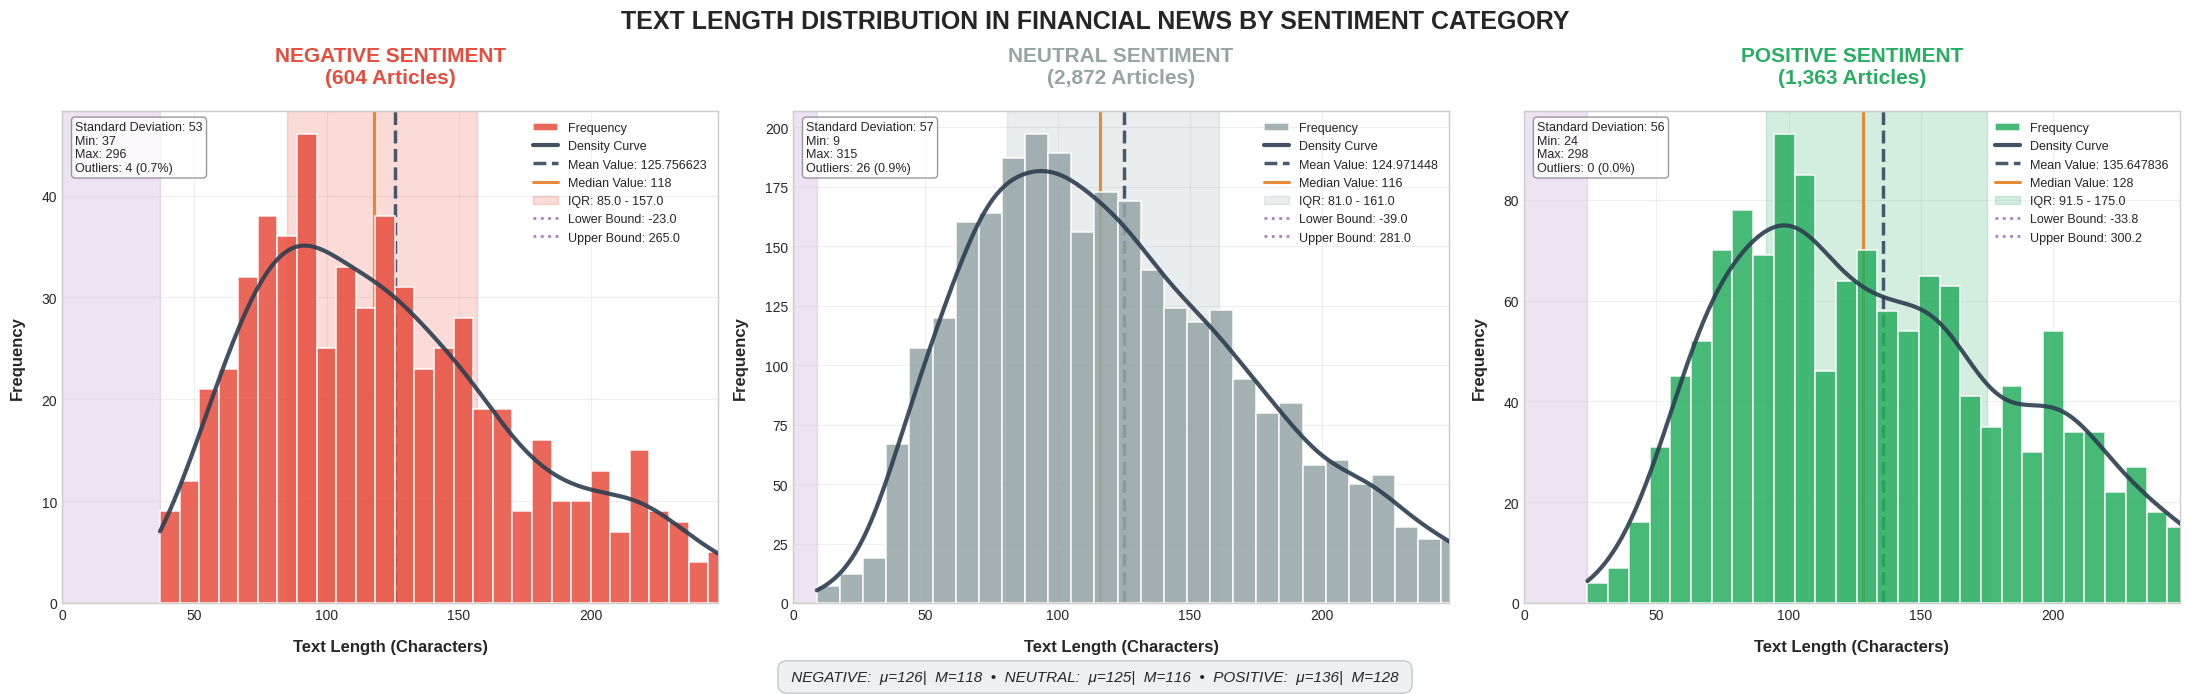

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# create figure dengan lebih proporsional dan enak dilihat
fig, axes = plt.subplots(1,3, figsize=(22, 6))
axes = axes.flatten()

sentiment_labels = {
    0:'NEGATIVE',
    1:'NEUTRAL',
    2:'POSITIVE'
}

colors = ['#e74c3c', '#95a5a6', '#27ae60']
light_colors = ['#fadbd8', '#f2f3f4', '#d5f5e3']

all_lengths = df_analisis['Text'].str.len()
x_limit = all_lengths.quantile(0.97)
outliers_info = {}


for label, ax in enumerate(axes):
  text_lengths = df_analisis[df_analisis['sentiment_decoded'] == label]['Text'].str.len()

  # Outliers Detection menggunakan IQR method
  q1 = text_lengths.quantile(0.25)
  q3 = text_lengths.quantile(0.75)
  iqr = q3-q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr

  # analysis outliers
  outliers = text_lengths[(text_lengths < lower_bound) | (text_lengths > upper_bound)]
  outliers_percentage = (len(outliers) / len(text_lengths)) * 100

  # simpan outlier info untuk summary
  outliers_info[label] = {
      'count': len(outliers),
      'percentage': outliers_percentage,
      'lower_bound': lower_bound,
      'upper_bound': upper_bound,
      'outliers_values': outliers
  }



  # Create histogram
  n, bins, patches = ax.hist(text_lengths, bins=35, color=colors[label],
                             alpha=0.85, edgecolor='white', linewidth=1.2,
                             density=False, zorder=3, label='Frequency')

  # smooting KDE curve
  if len(text_lengths) > 1:
    kde = gaussian_kde(text_lengths)
    x_range = np.linspace(text_lengths.min(),
                          text_lengths.max(), 300)
    kde_vals = kde(x_range) * len(text_lengths) * (bins[1] - bins[0])
    ax.plot(x_range, kde_vals, color='#2c3e50',
            linewidth=3, alpha=0.9, label='Density Curve', zorder=4)

  # statistics markers
  mean_val = text_lengths.mean()
  median_val = text_lengths.median()


  # vertical line untuk statistical marker
  ax.axvline(mean_val, color='#34495e', linestyle='--',
             linewidth=2.5,
             alpha=0.9, label=f'Mean Value: {mean_val:0f}',
             zorder=2)
  ax.axvline(median_val, color='#e67e22', linestyle='-', linewidth=2.2,
             alpha=0.9, label=f'Median Value: {median_val:.0f}',
             zorder=2)

  # shaded area untuk interquartile range
  ax.axvspan(q1,q3, alpha=0.2, color=colors[label],
            label=f'IQR: {q1:.1f} - {q3:.1f}', zorder=1)

  # Outliers Visualization highlight outlier bounds
  ax.axvline(lower_bound, color='#8e44ad', linestyle=':', linewidth=2,
             alpha=0.7, label=f'Lower Bound: {lower_bound:.1f}', zorder=2)
  ax.axvline(upper_bound, color='#8e44ad', linestyle=':', linewidth=2,
             alpha=0.7, label=f'Upper Bound: {upper_bound:.1f}', zorder=2)

  # shaded area untuk outliers regions
  ax.axvspan(text_lengths.min(), lower_bound, alpha=0.15, color='#8e44ad', zorder=0)


  # enhanced styling
  ax.set_title(f'{sentiment_labels[label]} SENTIMENT\n({len(text_lengths):,} Articles)',
                fontsize=15, fontweight='bold', pad=20, color=colors[label])


  ax.set_xlabel(
      'Text Length (Characters)',
      fontsize=12,
      fontweight='semibold',
      labelpad=12
  )
  ax.set_ylabel(
      'Frequency',
      fontsize=12,
      fontweight='semibold',
      labelpad=12
  )

  ax.tick_params(
      axis='both',
      which='major',
      labelsize=10,
  )

  ax.grid(
      True,
      alpha=0.3,
      zorder=1
  )

  ax.legend(
      fontsize=9,
      framealpha=0.95,
      loc='upper right',
      fancybox=True,
      shadow=True
  )

  ax.set_xlim(
      0,
      x_limit
  )


  # add some informative text in the plot
  stats_text = (f'Standard Deviation: {text_lengths.std():.0f}\n'
                f'Min: {text_lengths.min():.0f}\n'
                f'Max: {text_lengths.max():.0f}\n'
                f'Outliers: {len(outliers):,} ({outliers_percentage:.1f}%)')


  ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white',
                                             alpha=0.8, edgecolor='gray'), zorder=5)

# main title
plt.suptitle('TEXT LENGTH DISTRIBUTION IN FINANCIAL NEWS BY SENTIMENT CATEGORY',
             fontsize=18, fontweight='bold', y=1.07)

# footer dengan comparative analysis
comparison_text = []
for label in range(3):
  text_lengths = df_analisis[df_analisis['sentiment_decoded'] == label]['Text'].str.len()
  comparison_text.append(
      f' {sentiment_labels[label]}:  μ={text_lengths.mean():.0f}|  M={text_lengths.median():.0f} '
  )

fig.text(0.5, -0.05, " • ".join(comparison_text),
         ha='center',
         fontsize=11,
         style='italic',
         bbox=dict(boxstyle='round, pad=0.6',
                   facecolor="#ecf0f1",
                   edgecolor='#bdc3c7',
                   alpha=0.9))

plt.tight_layout()
plt.subplots_adjust(top=0.90, bottom=0.08)
plt.show()

## 5.4 Statistical Analysis and Report

In [ ]:
print(('\n' + '📊' + '='*80))
print('                   Comprehensive Text Length Statistics By Sentiment')
print('='*83)

for label in range(3):
  text_lengths = df_analisis[df_analisis['sentiment_decoded'] == label]['Text'].str.len()

  # Outlier calculations
  q1 = text_lengths.quantile(0.25)
  q3 = text_lengths.quantile(0.75)
  iqr = q3-q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  outliers = text_lengths[
      (
          text_lengths < lower_bound
      )  |

      (
          text_lengths > upper_bound
      )
  ]

  print(f'\n🎯 {sentiment_labels[label]} SENTIMENT')
  print(f'📈 Sample Size: {len(text_lengths):,} articles')
  print(f'📏 Central Tendency: ')
  print(f'                     --> Mean Value: {text_lengths.mean():.1f} chars')
  print(f'                     --> Median Value: {text_lengths.median():.1f} chars')
  print(f'                     --> Mode Value: {text_lengths.mode().iloc[0] if not text_lengths.mode().empty else 'N/A'} chars')
  print(f'📊 Dispersion:')
  print(f'                     --> Standard Deviation: {text_lengths.std():.2f} chars')
  print(f'                     --> Variance: {text_lengths.var():.2f}')
  print(f'                     --> Range: {text_lengths.min():.0f} - {text_lengths.max():.0f} chars')
  print(f'                     --> IQR: {text_lengths.quantile(0.75) - text_lengths.quantile(0.25):.1f} chars')
  print(f'📋 Percentiles:')
  print(f'                     --> 25th: {text_lengths.quantile(0.25):.1f} chars')
  print(f'                     --> 50th: {text_lengths.quantile(0.5):.1f} chars')
  print(f'                     --> 75th: {text_lengths.quantile(0.75):.1f} chars')
  print(f'                     --> 95th: {text_lengths.quantile(0.95):.1f} chars')
  print(f'🚨 Outliers Detection (IQR Method):')
  print(f'                                    ---> Lower Bound: {lower_bound:.1f} chars')
  print(f'                                    ---> Upper Bound: {upper_bound:1f} chars')
  print(f'                                    ---> Outliers Count: {len(outliers):,} articles')
  print(f'                                    ---> Outliers Percentage: {(len(outliers)/len(text_lengths))*100:.2f}%')

  if len(outliers) > 0:
    print(f'                                    ---> Outliers Range: {outliers.min():.0f} - {outliers.max():.0f} chars')
    print(f'                                    ---> Extreme Values:')
    extreme_outliers = outliers.nlargest(3)
    for i, val in enumerate(extreme_outliers):
      print(f'                                {i+1}, {val:.0f} chars')


print('\n' + '='*83)

# additional outlier summary
print('\n🔍 Outlier Summary Across Sentiment Categories:')
print('='*83)
for label in range(3):
  info = outliers_info.get(label, {})
  print(f'{sentiment_labels[label]}: {info.get("count", 0):,} outliers '
        f'({info.get('percentage',0):.1f}%)')
print(f'\n📝 Outlier Detection Method: IQR (Q1 - 1.5 * IQR, Q3 + 1.5 *IQR)')
print(f'💡 Recommendation: Consider Investigating Articles With Extreme Text Lengths')
print('='*83)


📊================================================================================
                   Comprehensive Text Length Statistics By Sentiment

🎯 NEGATIVE SENTIMENT
📈 Sample Size: 604 articles
📏 Central Tendency: 
                     --> Mean Value: 125.8 chars
                     --> Median Value: 118.0 chars
                     --> Mode Value: 87 chars
📊 Dispersion:
                     --> Standard Deviation: 52.90 chars
                     --> Variance: 2798.79
                     --> Range: 37 - 296 chars
                     --> IQR: 72.0 chars
📋 Percentiles:
                     --> 25th: 85.0 chars
                     --> 50th: 118.0 chars
                     --> 75th: 157.0 chars
                     --> 95th: 226.0 chars
🚨 Outliers Detection (IQR Method):
                                    ---> Lower Bound: -23.0 chars
                                    ---> Upper Bound: 265.000000 chars
                                    ---> Outliers Count: 4 articles
   

## 5.5 Data Visualization for Show Distribution of Overall Text Lengths

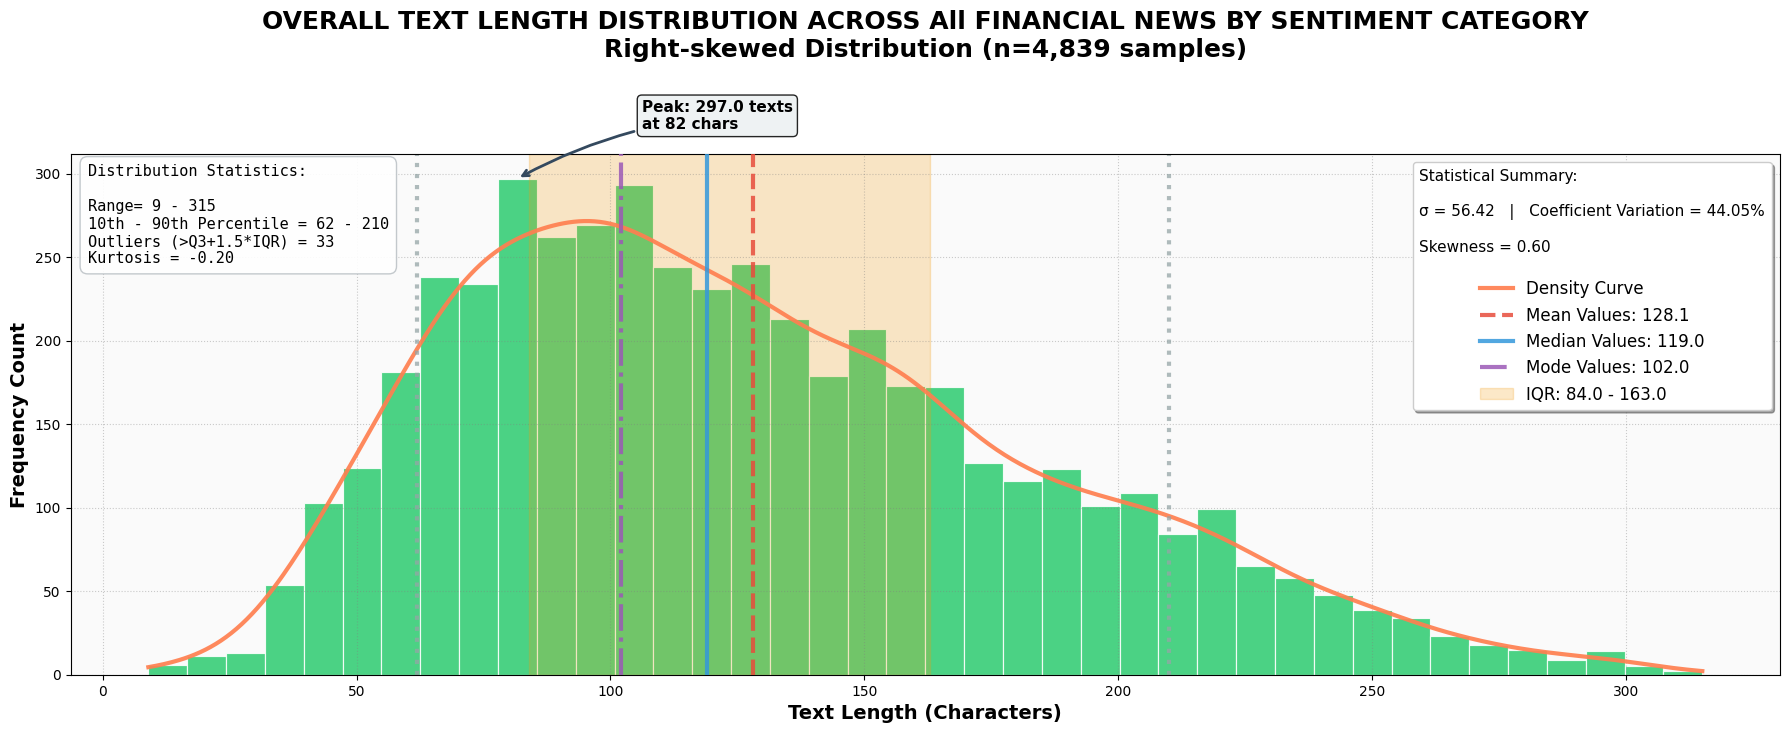

In [ ]:
plt.figure(figsize=(18,7.5))
plt.style.use('default')

# calculate comprehensive statistics
data = df_analisis['text_lengths']
mean_len = data.mean()
median_len = data.median()
std_len = data.std()
q25 = data.quantile(0.25)
q75 = data.quantile(0.75)
mode_len = data.mode().iloc[0] if not data.mode().empty else median_len
skewness = data.skew()
kurtosis = data.kurtosis()
cv = (std_len/mean_len)*100    # Coefficient Variation

# histogram plot
n, bins, patches = plt.hist(data, bins=40, alpha=0.86, color='#2ecc71',
                            edgecolor='white', linewidth=0.85, density=False)


# add KDE overlay
kde_x = np.linspace(data.min(),
                    data.max(),
                    600)
kde = stats.gaussian_kde(data)
kde_y = kde(kde_x) * len(data) * (bins[1] - bins[0])  # scale to match histogram
plt.plot(kde_x, kde_y, color='coral', linewidth=3,
         alpha=0.92, label='Density Curve')

# add statistical refrence line with enhanced styling
plt.axvline(mean_len, color='#e74c3c', linestyle='--', linewidth=3,
            alpha=0.85, label=f'Mean Values: {mean_len:.1f}', zorder=5)
plt.axvline(median_len, color='#3498db', linestyle='-', linewidth=3,
            alpha=0.85, label=f'Median Values: {median_len:.1f}', zorder=5)
plt.axvline(mode_len, color='#9b59b6', linestyle='-.', linewidth=3,
            alpha=0.85, label=f'Mode Values: {mode_len:.1f}', zorder=5)

# add quartile shading
plt.axvspan(q25,q75, alpha=0.23, color='#f39c12',
            label=f'IQR: {q25:.1f} - {q75:.1f}')

# add percentile marker
p90 = data.quantile(0.9)
p10 = data.quantile(0.1)
plt.axvline(p10, color='#95a5a6', linestyle=':',
            linewidth=3, alpha=0.75)
plt.axvline(p90, color='#95a5a6', linestyle=':',
            linewidth=3, alpha=0.75)

# enhanced title with statistical context
distribution_type = 'Right-skewed' if skewness > 0.5 else 'Left-skewed' if skewness < -0.5 else 'Approximately Normal'
plt.title(f'OVERALL TEXT LENGTH DISTRIBUTION ACROSS All FINANCIAL NEWS BY SENTIMENT CATEGORY\n'
          f'{distribution_type} Distribution (n={len(data):,} samples)',
          fontsize=18,
          fontweight='bold',
          pad=25,
          y=1.12)

# enhanced axis labels
plt.xlabel('Text Length (Characters)',
           fontsize=14, fontweight='semibold')
plt.ylabel('Frequency Count',
           fontsize=14, fontweight='semibold')

# format axes for better readability
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))


# enhanced legend with comprehensive statistics
legend_title = (f'Statistical Summary:\n\n'
                f'σ = {std_len:.2f}   |   Coefficient Variation = {cv:.2f}%\n\n'
                f'Skewness = {skewness:.2f}\n')

plt.legend(
    title=legend_title, loc='best', frameon=True,
    fancybox=True, shadow=True, fontsize=12,
    title_fontsize=11
)

# enhanced grid
plt.grid(True, linestyle=':', alpha=0.4, color='gray')
plt.gca().set_facecolor('#fafafa')

# add comprehensive statistics text box
stats_text = (f'Distribution Statistics:\n\n'
              f'Range= {data.min():.0f} - {data.max():.0f}\n'
              f'10th - 90th Percentile = {p10:.0f} - {p90:.0f}\n'
              f'Outliers (>Q3+1.5*IQR) = {len(data[data > q75 + 1.5 * (q75-q25)]):,}\n'
              f'Kurtosis = {kurtosis:.2f}')
plt.text(0.01, 0.98, stats_text, transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#bdc3c7'),
         fontsize=11, fontfamily='monospace')


# add annotation for peak
peak_idx = np.argmax(n)
peak_x = (bins[peak_idx] + bins[peak_idx + 1])/2
peak_y = n[peak_idx]
plt.annotate(f'Peak: {peak_y:.1f} texts\nat {peak_x:.0f} chars',
             xy=(peak_x, peak_y), xytext=(peak_x*1.3, peak_y*1.1),
             arrowprops=dict(arrowstyle='->',
                             connectionstyle='arc3,rad=0.1',
                             color='#34495e', lw=2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#ecf0f1', alpha=0.85),
             fontsize=11,
             fontweight='semibold')
plt.tight_layout()
plt.show()

## 5.6 Statistical Comprehensive

In [ ]:
print('\n' + '='*100)
print('Comprehensive Text Length Distribution Analysis')
print('='*100)

print(f'\nDatasets Overview:')
print(f'                   ---> Total Samples: {len(data):,}')
print(f'                   ---> Unique Text Lengths: {data.nunique():,}')
print(f'                   ---> Data Completeness: {(1 - data.isnull().sum()/len(data))*100:.2f}%')

print('\nCentral Tendency:')
print(f'                  ---> Mean Value: {mean_len:.1f} characters')
print(f'                  ---> Median Value: {median_len:.1f} characters')
print(f'                  ---> Mode: {mode_len:.1f} characters')

print('\nVariability:')
print(f'             ---> Standard Deviation: {std_len:.2f} characters')
print(f'             ---> Variance: {std_len**2:.2f} characters')
print(f'             ---> Coefficient of Variation: {cv:.2f}%')
print(f'             ---> Range: {data.max() - data.min():.1f} characters')

print('\nDistribution Shape:')
print(f'                   ---> Skewness: {skewness:.2f} ({'Right-skewed' if skewness > 0.5 else 'Left-skewed' if skewness < -0.5 else 'Approximately Symmetric'})')
print(f'                   ---> Kurtosis: {kurtosis:.2f} ({'Heavy-tailed' if kurtosis > 0 else 'Light-tailed'})')

print(f'\nPercentiles:')
percentiles = [10,25,50,75,90,95,99]
for p in percentiles:
  value = data.quantile(p/100)
  print(f'{p}th percentile: {value:.2f} characters')

print(f'\nOutliers Detection:')
iqr = q75-q25
lower_fence = q25-1.5*iqr
upper_fence = q75+1.5*iqr
outlier_low = len(data[data < lower_fence])
outlier_high = len(data[data > upper_fence])
print(f'Lower Outliers (< {lower_fence:.1f}) = {outlier_low:,} ({outlier_low/len(data)*100:.1f}%)')
print(f'Upper Outliers (> {upper_fence:.1f}) = {outlier_high:,} ({outlier_high/len(data)*100:.1f}%)')
print(f'Total Outliers = {outlier_low + outlier_high:,} ({(outlier_low+outlier_high)/len(data)*100:.1f}%)')


Comprehensive Text Length Distribution Analysis

Datasets Overview:
                   ---> Total Samples: 4,839
                   ---> Unique Text Lengths: 285
                   ---> Data Completeness: 100.00%

Central Tendency:
                  ---> Mean Value: 128.1 characters
                  ---> Median Value: 119.0 characters
                  ---> Mode: 102.0 characters

Variability:
             ---> Standard Deviation: 56.42 characters
             ---> Variance: 3183.48 characters
             ---> Coefficient of Variation: 44.05%
             ---> Range: 306.0 characters

Distribution Shape:
                   ---> Skewness: 0.60 (Right-skewed)
                   ---> Kurtosis: -0.20 (Light-tailed)

Percentiles:
10th percentile: 62.00 characters
25th percentile: 84.00 characters
50th percentile: 119.00 characters
75th percentile: 163.00 characters
90th percentile: 210.00 characters
95th percentile: 233.00 characters
99th percentile: 275.00 characters

Outliers Detection

In [ ]:
def plot_sentiment_distribution(df_analisis,
                                sentiment_col = 'Sentiment',
                                order=['negative', 'positive', 'neutral'],
                                figsize=(15,7),
                                palette_name='mako'):
  # menghitung jumlah per sentiment
  aa = (df_analisis.groupby(sentiment_col).size().reset_index(name='count'))
  total = aa['count'].sum()
  aa['percent'] = (aa['count']/total*100).round(2)

  # menghitung percent
  present_order = [c for c in order if c in aa[sentiment_col].unique()]
  aa[sentiment_col] = pd.Categorical(aa[sentiment_col],
                                     categories=present_order,
                                     ordered=True)
  total = aa['count'].sum()
  aa = aa.sort_values(by=sentiment_col).reset_index(drop=True)


  title_lines = [f'{row[sentiment_col]}: {row['percent']}% ({row['count']:,} articles)' for _, row in aa.iterrows()]
  total_line = f'Total Articles: {total:,} articles'
  title = 'Percent of Articles By Sentiment Financial News:\n' + '\n'.join(title_lines) + f'\n\n{total_line}'

  # membuat barplot
  sns.set_style('whitegrid')
  plt.figure(figsize=figsize)
  palette = sns.color_palette(palette_name, n_colors=len(aa))

  ax = sns.barplot(data=aa,
                   x=sentiment_col,
                   y='percent',
                   palette=palette,
                   edgecolor='black',
                   linewidth=0.8,
                   saturation=0.95)

  ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
  ax.set_ylim(0, max(aa['percent'].max() * 1.2, 10))

  # membuat label dan title
  ax.set_title(title, fontdict={'size':12}, pad=12)
  ax.set_xlabel("Sentiment Categories", fontdict={'size':12})
  ax.set_ylabel("Percent (%)", fontdict={'size':12})

  # annotate bars
  for i, p in enumerate(ax.patches):
    height = p.get_height()
    percent_label = f'{height:.2f}%'
    count = int(aa.loc[i, 'count'])
    count_label = f'n={count:,}'

    # percent diatas bar
    ax.annotate(percent_label, xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0,6),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=11, weight='semibold')

    # menghitung n didalam bar
    inside_y = height*0.55
    if height >= 6:
      ax.annotate(count_label,
                  xy=(p.get_x() + p.get_width() / 2, inside_y),
                  ha='center', va='center', fontsize=11, color='white')
    else:
      ax.annotate(count_label,
                  xy=(p.get_x() + p.get_width() / 2, height),
                  xytext=(0,-14),
                  textcoords='offset points',
                  ha='center', va='top', fontsize=11)

  sns.despine(left=False, bottom=True),
  plt.tight_layout()
  plt.show()

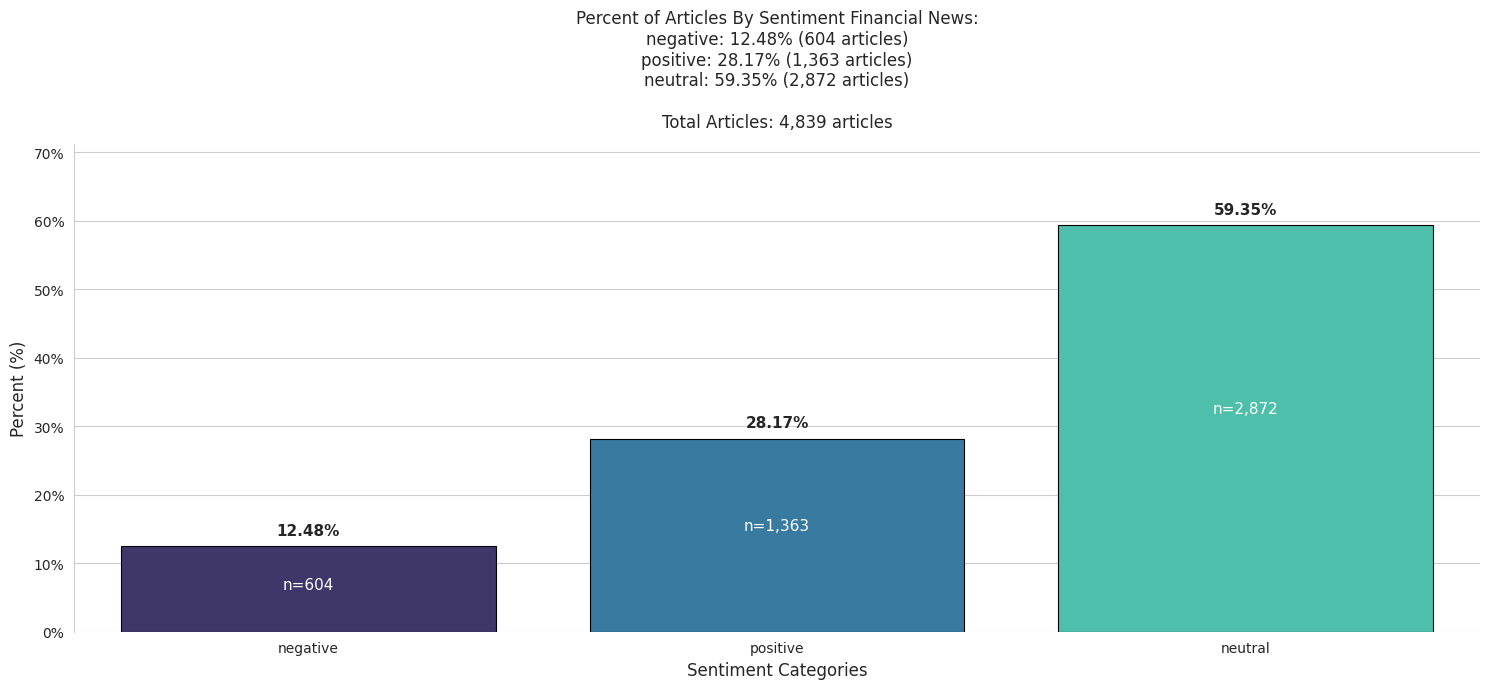

In [ ]:
# memanggil function
plot_sentiment_distribution(df_analisis)

# **6. Pre-processing**

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):
  text=text.lower()
  text=re.sub(r'https\S+|https\S+', '', text)
  text=re.sub(r'\S+@\S+\.\S+', '', text)
  text=re.sub(r'@\w+|#\w+', '', text)
  text=re.sub(r'<.*?>', '', text)
  text=re.sub(r'\d+', '', text)
  text=re.sub(r'[^\w\s]', '', text)
  text=re.sub(r'\s+', ' ', text).strip()

  words = text.split()
  words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
  return " ".join(words)

In [ ]:
df_analisis['clean_text'] = df['Text'].apply(clean_text)
check_values(df_analisis)

,Columns,Dtype,Null,NullPercentage,Unique,Values
0,Sentiment,object,0,100.0,3,"[neutral, negative, positive]"
1,Text,object,0,100.0,4837,[Technopolis plans to develop in stages an are...
2,sentiment_decoded,int64,0,100.0,3,"[1, 0, 2]"
3,text_lengths,int64,0,100.0,285,"[190, 228, 206, 203, 178, 193, 125, 122, 103, ..."
4,clean_text,object,0,100.0,4759,[technopolis plan develop stage area less squa...


In [ ]:
df_analisis

,Sentiment,Text,sentiment_decoded,text_lengths,clean_text
0,neutral,Technopolis plans to develop in stages an area...,1,190,technopolis plan develop stage area less squar...
1,negative,The international electronic industry company ...,0,228,international electronic industry company elco...
2,positive,With the new production plant the company woul...,2,206,new production plant company would increase ca...
3,positive,According to the company 's updated strategy f...,2,203,according company updated strategy year baswar...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...,2,178,financing aspocomp growth aspocomp aggressivel...
...,...,...,...,...,...
4840,negative,LONDON MarketWatch -- Share prices ended lower...,0,144,london marketwatch share price ended lower lon...
4841,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...,1,148,rinkuskiai beer sale fell per cent million lit...
4842,negative,Operating profit fell to EUR 35.4 mn from EUR ...,0,108,operating profit fell eur mn eur mn including ...
4843,negative,Net sales of the Paper segment decreased to EU...,0,226,net sale paper segment decreased eur mn second...


## 6.1 Text Analysis

In [ ]:
df_analisis = df_analisis[['clean_text', 'Sentiment']]
df_analisis.head(6)

,clean_text,Sentiment
0,technopolis plan develop stage area less squar...,neutral
1,international electronic industry company elco...,negative
2,new production plant company would increase ca...,positive
3,according company updated strategy year baswar...,positive
4,financing aspocomp growth aspocomp aggressivel...,positive
5,last quarter componenta net sale doubled eurm ...,positive


In [ ]:
classes = df_analisis['Sentiment'].unique()
max_count = df_analisis['Sentiment'].value_counts().max()
df_list = []

for c in classes:
  df_class = df_analisis[df_analisis['Sentiment'] == c]
  df_unsampled = resample(
      df_class,
      replace=True,
      n_samples=max_count,
      random_state=42
  )
  df_list.append(df_unsampled)

df_balanced = pd.concat(df_list)
df_balanced = df_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [ ]:
print(df_balanced['Sentiment'].value_counts())

Sentiment
neutral     2872
positive    2872
negative    2872
Name: count, dtype: int64


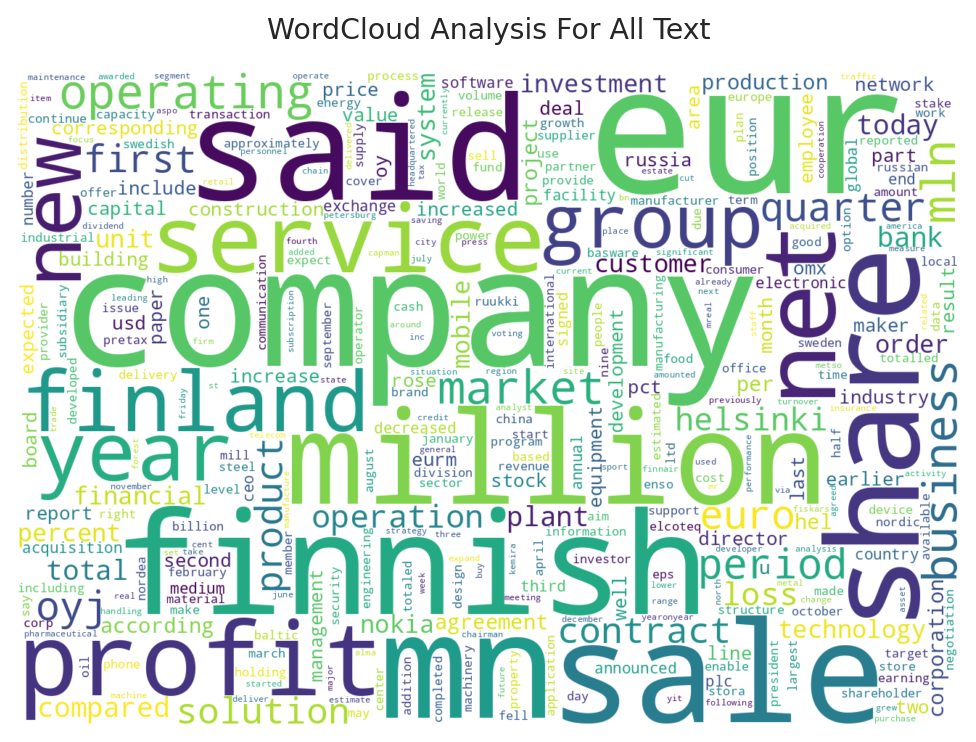



Total Words Processed: 58121
Unique Words In Clouds: 350


In [ ]:
all_text = " ".join(df_analisis['clean_text'])
wc = WordCloud(
    width=1300,
    height=900,
    background_color='white',
    colormap='viridis',
    relative_scaling=0.3,
    max_font_size=250,
    min_font_size=10,
    collocations=False,
    random_state=42,
    prefer_horizontal=0.8,
    contour_width=1,
    contour_color='steelblue',
    max_words=350
).generate(all_text)

plt.figure(figsize=(22,5), dpi=170, facecolor='white')
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Analysis For All Text", y=1.03)
plt.tight_layout(pad=3.0)
plt.show()
print('\n')
print(f'Total Words Processed: {len(all_text.split())}')
print(f'Unique Words In Clouds: {len(wc.words_)}')

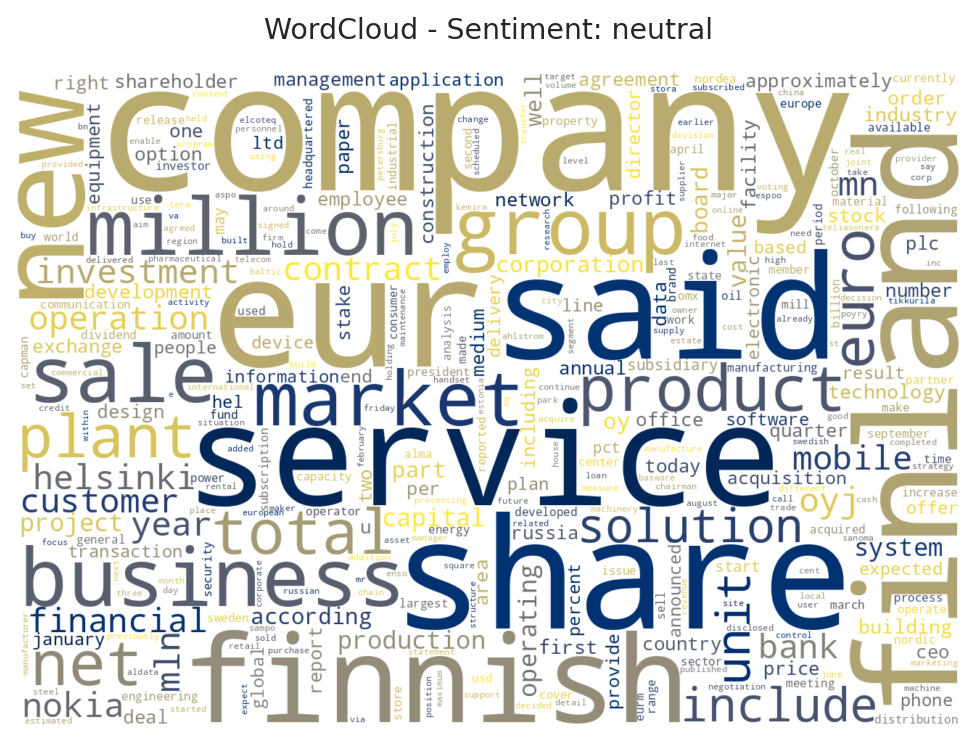

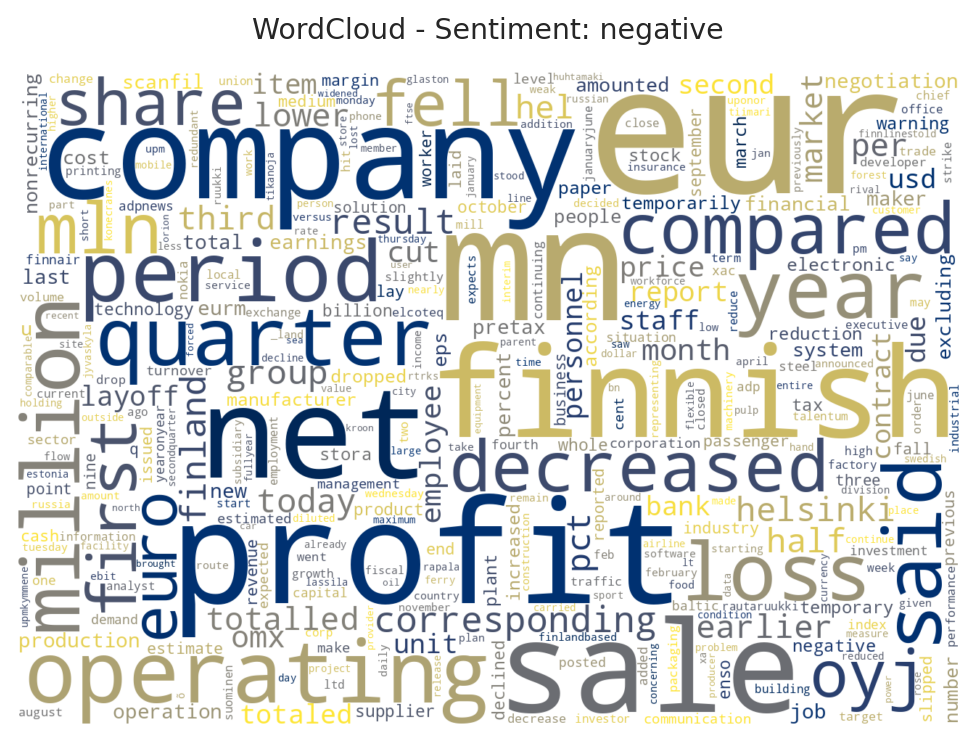

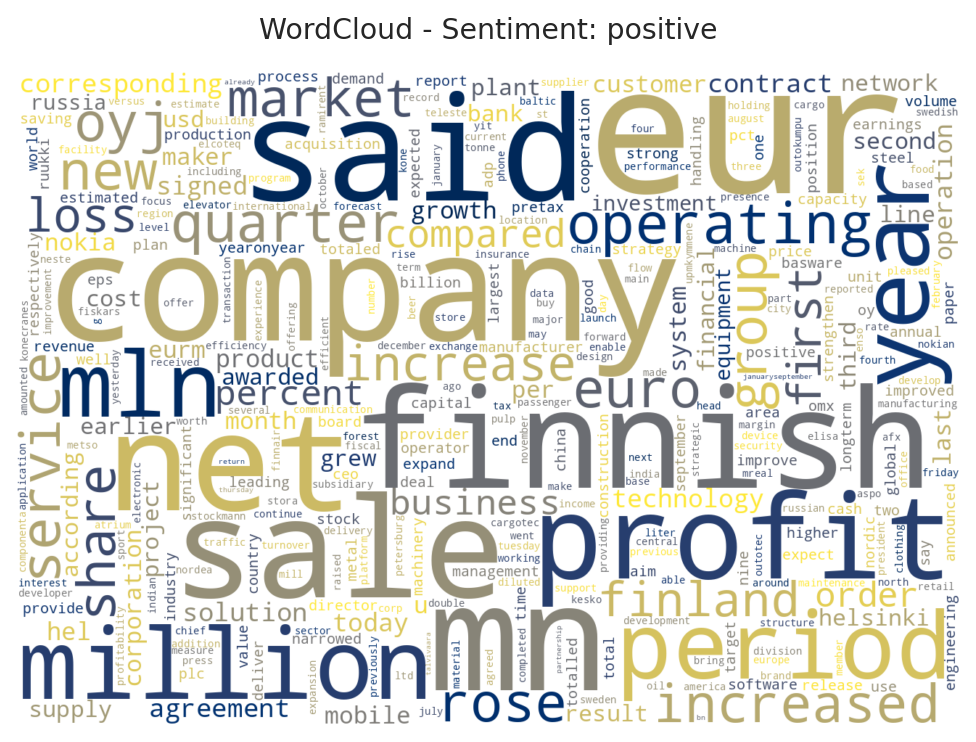

In [ ]:
unique_classes = df_analisis['Sentiment'].unique()

for i in unique_classes:
  text = " ".join(df_analisis[df_analisis['Sentiment'] == i]['clean_text'])
  wc = WordCloud(
      width=1300,
      height=900,
      background_color='white',
      colormap='cividis',
      relative_scaling=0.3,
      max_font_size=250,
      min_font_size=10,
      collocations=False,
      random_state=42,
      prefer_horizontal=0.8,
      contour_width=1,
      contour_color='steelblue',
      max_words=350
  ).generate(text)

  plt.figure(figsize=(22,5), dpi=170, facecolor='white')
  plt.imshow(wc, interpolation='bilinear')
  plt.axis('off')
  plt.title(f'WordCloud - Sentiment: {i}', y=1.03)
  plt.tight_layout(pad=3.0)
  plt.show()

In [ ]:
def plot_top_words(df_analisis,
                   sentiment_col='Sentiment',
                   text_col='clean_text',
                   top_n=20,
                   figsize=(18,10),
                   color_palette=None,
                   marker_style='o-',
                   line_width=2,
                   horizontal=False,
                   title_fontsize=16,
                   label_fontsize=12,
                   show_values=True,
                   exclude_words=None,
                   subplot_layout=None):

  plt.style.use('seaborn-v0_8-whitegrid')

  # mendapatkan sentiment dan setup colors
  sentiments = sorted(df_analisis[sentiment_col].unique())
  n_sentiments = len(sentiments)

  # menentukan subplot layout
  if subplot_layout is None:
    rows = int(np.ceil(n_sentiments/2))
    cols = min(2, n_sentiments)
  else:
    rows, cols = subplot_layout


  # membuat color palette
  if color_palette is None:
    colors = plt.cm.Set3(np.linspace(0,1,n_sentiments))
  elif isinstance(color_palette, str):
    colors = sns.color_palette(color_palette, n_sentiments)
  else:
    colors = color_palette


  # membuat figure
  fig, axes = plt.subplots(rows, cols, figsize=figsize)
  if n_sentiments == 1:
    axes = np.array([axes])
  axes = axes.flatten()

  # process each sentiment
  for idx, sentiment in enumerate(sentiments):
    if idx >= len(axes):
      break
    ax = axes[idx]

    texts = df_analisis[df_analisis[sentiment_col] == sentiment][text_col]
    all_words = " ".join(texts).split()

    # filter out excluded word
    if exclude_words:
      all_words = [word for word in all_words if word not in exclude_words]

    # count words and get top N
    word_counts = Counter(all_words).most_common(top_n)
    if not word_counts:
      ax.text(0.5, 0.5, 'No Data', ha='center',
              va='center', transform=ax.transAxes, fontsize=label_fontsize)
      ax.set_title(f'Sentiment: {sentiment}',
                    fontsize=title_fontsize,
                    pad=20)

      continue

    words = [w for w, c in word_counts]
    counts = [c for w, c in word_counts]

    # membuat ke linechart
    x_pos = np.arange(len(words))
    line = ax.plot(x_pos, counts, marker_style, color=colors[idx],
                   linewidth=line_width, markersize=6, alpha=0.8, label=f'Sentiment: {sentiment}')
    # custom sumbu x
    ax.set_xticks(x_pos)
    ax.set_xticklabels(words, rotation=45, ha='right',
                        fontsize=label_fontsize-2)
    ax.set_ylabel('Word Frequency', fontsize=label_fontsize)
    ax.set_xlabel('Words', fontsize=label_fontsize)

    # menambahkan value labels
    if show_values:
      for i, (x,y) in enumerate(zip(x_pos, counts)):
        ax.annotate(f'{y}', (x,y), textcoords='offset points',
                    xytext=(0,5), ha='center', fontsize=label_fontsize-3,
                    alpha=0.8)

    # custom subplot
    ax.set_title(f'Sentiment: {sentiment}\nTop {top_n} Words', y=0.96,
                 fontsize=title_fontsize, pad=20,
                 fontweight='bold')
    ax.spines[
        [
            'top',
            'right'
        ]
    ].set_visible(False)
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

    # menambahkan fill bawah garis untuk visual yang lebih baik.
    ax.fill_between(x_pos, counts,
                    alpha=0.2, color=colors[idx])

  # hide empty subplots
  for idx in range(len(sentiments), len(axes)):
    axes[idx].set_visible(False)

  # adjust layout
  plt.tight_layout()
  plt.show()
  return fig, axes

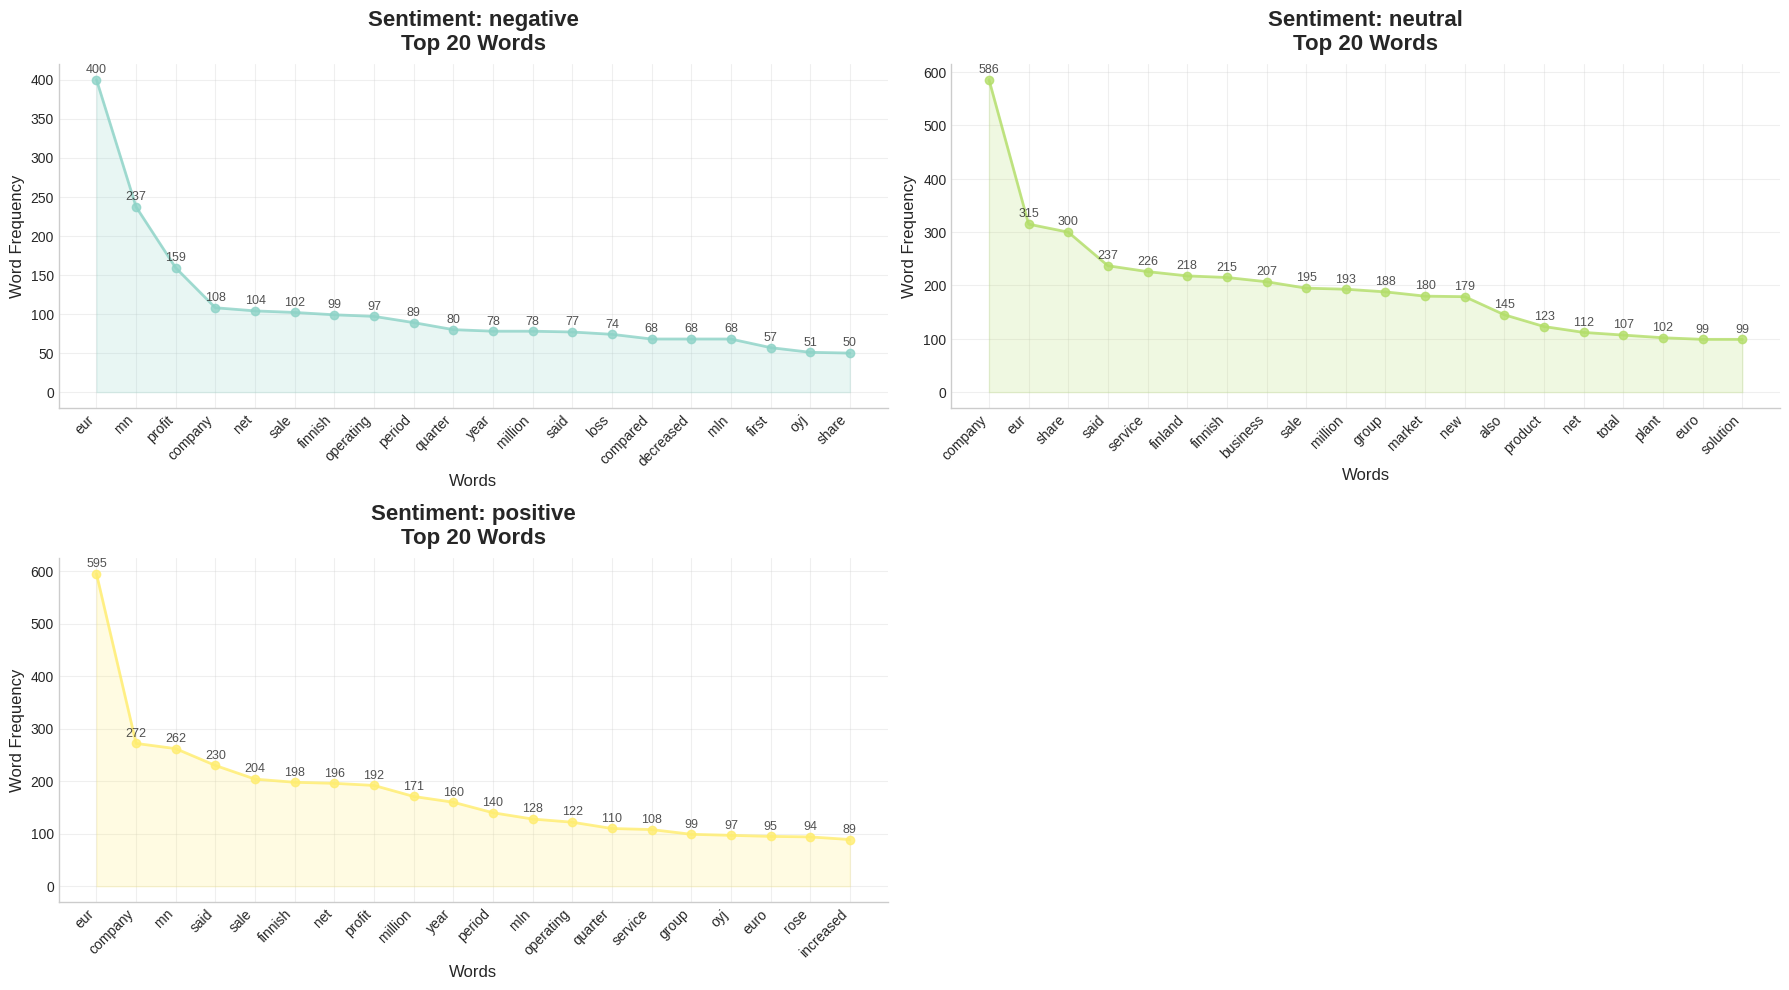

(<Figure size 1800x1000 with 4 Axes>,
 array([<Axes: title={'center': 'Sentiment: negative\nTop 20 Words'}, xlabel='Words', ylabel='Word Frequency'>,
        <Axes: title={'center': 'Sentiment: neutral\nTop 20 Words'}, xlabel='Words', ylabel='Word Frequency'>,
        <Axes: title={'center': 'Sentiment: positive\nTop 20 Words'}, xlabel='Words', ylabel='Word Frequency'>,
        <Axes: >], dtype=object))

In [ ]:
plot_top_words(df_analisis)

In [ ]:
mapping = {
    'positive': 1,
    'neutral': 0,
    'negative': -1
}

df_balanced['sentiment_num'] = df_balanced['Sentiment'].map(mapping)
df_balanced

,clean_text,Sentiment,sentiment_num
0,alexandria va oct hansotto scheck espoo finlan...,neutral,0
1,boomerang boat net sale eur mn made operating ...,neutral,0
2,priority strengthen company balance sheet incr...,positive,1
3,performance impacted consolidation trend telec...,negative,-1
4,capital expenditure energy efficiency unfortun...,negative,-1
...,...,...,...
8611,finnish construction company yit reducing numb...,negative,-1
8612,finnish scanfil system supplier contract manuf...,negative,-1
8613,viking line canceled service,negative,-1
8614,company delivered technical infrastructure use...,neutral,0


In [ ]:
def check_values(df_balanced):
  data = []

  for col in df_balanced.columns:
    data.append(
        [
            col, \
            df_balanced[col].dtype, \
            df_balanced[col].isna().sum(), \
            round(100 + (df_balanced[col].isna().sum() / len(df_balanced)), 2), \
            df_balanced[col].nunique(), \
            df_balanced[col].unique()
        ]
    )
  return pd.DataFrame(columns=[
      'Columns',
      'Dtype',
      'Null',
      'NullPercentage',
      'Unique',
      'Values'
  ], data=data)

In [ ]:
check_values(df_balanced)

,Columns,Dtype,Null,NullPercentage,Unique,Values
0,clean_text,object,0,100.0,3487,[alexandria va oct hansotto scheck espoo finla...
1,Sentiment,object,0,100.0,3,"[neutral, positive, negative]"
2,sentiment_num,int64,0,100.0,3,"[0, 1, -1]"


In [ ]:
df_balanced = df_balanced.reset_index(drop=True)
label_map = {
    -1:0,
    0:1,
    1:2
}


df_balanced["label_id"] = df_balanced['sentiment_num'].map(label_map)
texts = df_balanced['clean_text'].astype(str).tolist()
labels = df_balanced['label_id'].tolist()

In [ ]:
check_values(df_balanced)

,Columns,Dtype,Null,NullPercentage,Unique,Values
0,clean_text,object,0,100.0,3487,[alexandria va oct hansotto scheck espoo finla...
1,Sentiment,object,0,100.0,3,"[neutral, positive, negative]"
2,sentiment_num,int64,0,100.0,3,"[0, 1, -1]"
3,label_id,int64,0,100.0,3,"[1, 2, 0]"


In [ ]:
texts[10]

'finnish plumbing heating system supplier uponor net sale continuing business operation decreased eur mn julyseptember compared eur mn third quarter'

In [ ]:
def printData(data):
  for item in data:
    print(item)
printData(texts)

alexandria va oct hansotto scheck espoo finland developed method identifying remote radio unit communication system
boomerang boat net sale eur mn made operating profit eur mn
priority strengthen company balance sheet increase cash flow ceo hannu krook said
performance impacted consolidation trend telecom sector overall structural change contract manufacturing market telecommunication technology industrial electronics
capital expenditure energy efficiency unfortunately fallen along decline economy
u energy executive say high steel price threatening energy exploration
according deputy md pekka silvennoinen aim double turnover next three year
also strong asset electronic medium employing increase percent last year
release company said vocollect customer north america take advantage voice directed warehousing solution increase warehouse efficiency productivity gain discounted price
commencing construction work pearl plaza significant step russian project
finnish plumbing heating system su

In [ ]:
for i, (text, label) in enumerate(zip(texts, labels)):
  if i >= 20:
    break
  print(f'[{i}] {text} --> {label}')

[0] alexandria va oct hansotto scheck espoo finland developed method identifying remote radio unit communication system --> 1
[1] boomerang boat net sale eur mn made operating profit eur mn --> 1
[2] priority strengthen company balance sheet increase cash flow ceo hannu krook said --> 2
[3] performance impacted consolidation trend telecom sector overall structural change contract manufacturing market telecommunication technology industrial electronics --> 0
[4] capital expenditure energy efficiency unfortunately fallen along decline economy --> 0
[5] u energy executive say high steel price threatening energy exploration --> 0
[6] according deputy md pekka silvennoinen aim double turnover next three year --> 2
[7] also strong asset electronic medium employing increase percent last year --> 2
[8] release company said vocollect customer north america take advantage voice directed warehousing solution increase warehouse efficiency productivity gain discounted price --> 2
[9] commencing con

## 6.2 Embedding model

In [ ]:
# checkpoints
embed_model = SentenceTransformer("all-MiniLM-L6-v2")
embed_model

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

In [ ]:
embeddings = embed_model.encode(
    texts,
    show_progress_bar=True,
    convert_to_numpy=True
)

embeddings

Batches:   0%|          | 0/270 [00:00<?, ?it/s]

array([[-0.05396901,  0.03002022, -0.11760808, ...,  0.10315611,
        -0.11147936, -0.03532725],
       [-0.00559015,  0.01641759,  0.00303736, ..., -0.05520454,
         0.00526938,  0.03442729],
       [-0.08695482,  0.02065012, -0.00012768, ..., -0.04557312,
         0.05394115,  0.01949072],
       ...,
       [-0.0726407 , -0.01162068,  0.02257478, ..., -0.05846131,
        -0.02619504, -0.04562342],
       [-0.02197924, -0.00490713, -0.01540394, ..., -0.01770866,
         0.05195568, -0.03748249],
       [-0.00247777, -0.03408638,  0.06096681, ..., -0.05945336,
         0.12211114,  0.06140132]], dtype=float32)

## 6.3 Train_test_split Data

In [ ]:
X_train_emb, X_test_emb, y_train, y_test, idx_train, idx_test = train_test_split(
    embeddings,
    labels,
    df_balanced.index.values, test_size=0.21,
    random_state=42,
    stratify=labels
)

## 6.4 Mixture of Experts (MoE) Model

### 6.4.1 Struktur Data dan Dataset: pre-computed embeddings

In [ ]:
class MoEDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.float32)   # input embeddings
    self.y = torch.tensor(y, dtype=torch.long)   # labels

  def __len__(self):
    return self.X.shape[0]

  def __getitem__(self, i):
    return self.X[i], self.y[i]

train_ds = MoEDataset(X_train_emb, y_train)
test_ds = MoEDataset(X_test_emb, y_test)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

### 6.4.2 Activation Function: SwiGLU (SiLU (Sigmoid Linear Unit) X GLU (Gate Linear Unit))

In [ ]:
class SwiGLU(nn.Module):
  def __init__(self, dim):
    super().__init__()
    self.fc1 = nn.Linear(dim, dim)
    self.fc2 = nn.Linear(dim, dim)

  def forward(self, x):
    return F.silu(self.fc1(x)) * self.fc2(x)

### 6.4.3 Expert Network: feed-forward network

In [ ]:
class Expert(nn.Module):
  def __init__(self, dim, hidden_mult=4):
    super().__init__()
    self.fc1 = nn.Linear(dim, dim*hidden_mult)       # Expansion
    self.act = SwiGLU(dim*hidden_mult)               # activation
    self.fc2 = nn.Linear(dim*hidden_mult, dim)       # compression

  def forward(self, x):
    return self.fc2(self.act(self.fc1(x)))

### 6.4.4 Core MoE Architecture

In [ ]:
class MoEHead(nn.Module):
  def __init__(self, dim, num_experts=4, k=2, num_classes=3):
    super().__init__()
    self.router = nn.Linear(dim, num_experts)                     # routing mechanism
    self.experts = nn.ModuleList([Expert(dim) for _ in range(num_experts)])
    self.k = k                                        # Top-k experts
    self.classifier = nn.Linear(dim, num_classes)   # final classification


  # forward pass flow:
  # 1. Routing Mechanism
  def forward(self, x):
    gate_logits = self.router(x)     # [batch_size, num_expert]
    gate_probs = F.softmax(gate_logits, dim=-1)   # probabilitas setiap expert
    topk_vals, topk_idx = torch.topk(gate_probs, self.k, dim=-1)    # pilih top-k expert
    batch_size = x.size(0)
    expert_out = torch.zeros(batch_size, x.size(1), device=x.device)

    # 2. expert selection and weighted combination
    for i in range(self.k):
      idx = topk_idx[:,i]           # indeks expert
      w = topk_vals[:,i].unsqueeze(-1)  # weight dari router
      expert_inputs = x
      selected = torch.stack(
          [
              self.experts[int(j)](expert_inputs[t]).unsqueeze(0) for t, j in enumerate(idx)
          ],
          dim=0
      ).squeeze(1)

      expert_out = expert_out + w * selected
    logits = self.classifier(expert_out)

    return logits, gate_probs

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
moe = MoEHead(dim=X_train_emb.shape[1],
              num_experts=4,
              k=2,
              num_classes=3).to(device)
optimizer = torch.optim.Adam(moe.parameters(), lr=5e-4)
criterion = nn.CrossEntropyLoss()

In [ ]:
device

device(type='cuda')

In [ ]:
moe

MoEHead(
  (router): Linear(in_features=384, out_features=4, bias=True)
  (experts): ModuleList(
    (0-3): 4 x Expert(
      (fc1): Linear(in_features=384, out_features=1536, bias=True)
      (act): SwiGLU(
        (fc1): Linear(in_features=1536, out_features=1536, bias=True)
        (fc2): Linear(in_features=1536, out_features=1536, bias=True)
      )
      (fc2): Linear(in_features=1536, out_features=384, bias=True)
    )
  )
  (classifier): Linear(in_features=384, out_features=3, bias=True)
)

In [ ]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0005
    maximize: False
    weight_decay: 0
)

In [ ]:
criterion

CrossEntropyLoss()

In [ ]:
for epoch in range(12):
  moe.train()
  loop = tqdm(
      train_loader,
      desc=f'Mixture of Experts (MoE) Train Epoch {epoch+1}'
  )

  for Xb, yb in loop:
    Xb = Xb.to(device)
    yb = yb.to(device)
    logits, gate = moe(Xb)
    loss = criterion(logits, yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loop.set_postfix(loss=loss.item())

  moe.eval()
  all_preds_moe = []
  with torch.no_grad():
    for Xb, _ in test_loader:
      Xb = Xb.to(device)
      logits, _ = moe(Xb)
      preds = torch.argmax(logits, dim=-1).cpu().numpy()
      all_preds_moe.extend(preds.tolist())

  print('Mixture of Experts (MoE) Testing Accuracy:', accuracy_score(y_test, all_preds_moe))
  print(classification_report(y_test, all_preds_moe, target_names=["Negative", "Neutral", "Positive"], digits=4))

Mixture of Experts (MoE) Train Epoch 1: 100%|██████████| 107/107 [00:13<00:00,  8.23it/s, loss=0.692]


Mixture of Experts (MoE) Testing Accuracy: 0.7524861878453039
              precision    recall  f1-score   support

    Negative     0.8095    0.9088    0.8562       603
     Neutral     0.7455    0.6169    0.6751       603
    Positive     0.6972    0.7318    0.7141       604

    accuracy                         0.7525      1810
   macro avg     0.7507    0.7525    0.7485      1810
weighted avg     0.7507    0.7525    0.7485      1810



Mixture of Experts (MoE) Train Epoch 2: 100%|██████████| 107/107 [00:13<00:00,  7.84it/s, loss=0.379]


Mixture of Experts (MoE) Testing Accuracy: 0.7740331491712708
              precision    recall  f1-score   support

    Negative     0.8752    0.8607    0.8679       603
     Neutral     0.7063    0.7579    0.7312       603
    Positive     0.7456    0.7036    0.7240       604

    accuracy                         0.7740      1810
   macro avg     0.7757    0.7741    0.7744      1810
weighted avg     0.7757    0.7740    0.7743      1810



Mixture of Experts (MoE) Train Epoch 3: 100%|██████████| 107/107 [00:12<00:00,  8.51it/s, loss=0.453]


...

Mixture of Experts (MoE) Testing Accuracy: 0.8994475138121547
              precision    recall  f1-score   support

    Negative     0.9214    0.9718    0.9459       603
     Neutral     0.9020    0.8391    0.8694       603
    Positive     0.8744    0.8874    0.8809       604

    accuracy                         0.8994      1810
   macro avg     0.8992    0.8995    0.8987      1810
weighted avg     0.8992    0.8994    0.8987      1810



Mixture of Experts (MoE) Train Epoch 11: 100%|██████████| 107/107 [00:13<00:00,  8.07it/s, loss=0.0713]


Mixture of Experts (MoE) Testing Accuracy: 0.9082872928176795
              precision    recall  f1-score   support

    Negative     0.9464    0.9668    0.9565       603
     Neutral     0.8731    0.8789    0.8760       603
    Positive     0.9046    0.8791    0.8917       604

    accuracy                         0.9083      1810
   macro avg     0.9081    0.9083    0.9081      1810
weighted avg     0.9081    0.9083    0.9081      1810



Mixture of Experts (MoE) Train Epoch 12: 100%|██████████| 107/107 [00:12<00:00,  8.41it/s, loss=0.0304]


Mixture of Experts (MoE) Testing Accuracy: 0.9110497237569061
              precision    recall  f1-score   support

    Negative     0.9502    0.9502    0.9502       603
     Neutral     0.9031    0.8657    0.8840       603
    Positive     0.8808    0.9172    0.8986       604

    accuracy                         0.9110      1810
   macro avg     0.9114    0.9110    0.9110      1810
weighted avg     0.9114    0.9110    0.9109      1810



## 6.5 Meta-MoE Model

In [ ]:
tfidf = TfidfVectorizer(max_features=28100,
                        ngram_range=(1,2))
tfidf

TfidfVectorizer(max_features=28100, ngram_range=(1, 2))

In [ ]:
tfidf_fit_texts = df_balanced[
    'clean_text'
].astype(str).tolist()

tfidf_fit_texts

['alexandria va oct hansotto scheck espoo finland developed method identifying remote radio unit communication system',
 'boomerang boat net sale eur mn made operating profit eur mn',
 'priority strengthen company balance sheet increase cash flow ceo hannu krook said',
 'performance impacted consolidation trend telecom sector overall structural change contract manufacturing market telecommunication technology industrial electronics',
 'capital expenditure energy efficiency unfortunately fallen along decline economy',
 'u energy executive say high steel price threatening energy exploration',
 'according deputy md pekka silvennoinen aim double turnover next three year',
 'also strong asset electronic medium employing increase percent last year',
 'release company said vocollect customer north america take advantage voice directed warehousing solution increase warehouse efficiency productivity gain discounted price',
 'commencing construction work pearl plaza significant step russian proj

In [ ]:
tfidf_matrix = tfidf.fit_transform(tfidf_fit_texts)
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 181348 stored elements and shape (8616, 28100)>

In [ ]:
X_train_tfidf = tfidf_matrix[idx_train]
X_test_tfidf = tfidf_matrix[idx_test]

In [ ]:
agent2 = LogisticRegression(max_iter=1300)
agent2

LogisticRegression(max_iter=1300)

In [ ]:
agent2.fit(X_train_tfidf, np.array(y_train))
agent2_preds = agent2.predict(X_test_tfidf)
agent2_proba = agent2.predict_proba(X_test_tfidf)

In [ ]:
agent3 = RandomForestClassifier(n_estimators=260, random_state=42)
agent3

RandomForestClassifier(n_estimators=260, random_state=42)

In [ ]:
agent3.fit(X_train_tfidf, np.array(y_train))
agent3_preds = agent3.predict(X_test_tfidf)
agent3_proba = agent3.predict_proba(X_test_tfidf)

In [ ]:
def moe_predict_proba(emb_array):
  moe.eval()
  with torch.no_grad():
    X = torch.tensor(emb_array,
                     dtype=torch.float32).to(device)
    logits, _ = moe(X)
    probs = F.softmax(logits, dim=-1).cpu().numpy()
  return probs

In [ ]:
moe_test_proba = moe_predict_proba(X_test_emb)
meta_X = np.hstack(
    [
        moe_test_proba,
        agent2_proba,
        agent3_proba
    ]
)

meta_y = np.array(y_test)

meta_train_moe_proba = moe_predict_proba(X_train_emb)
meta_train_agent2_proba = agent2.predict_proba(X_train_tfidf)
meta_train_agent3_proba = agent3.predict_proba(X_train_tfidf)
meta_X_train = np.hstack(
    [
        meta_train_moe_proba,
        meta_train_agent2_proba,
        meta_train_agent3_proba
    ]
)

meta_y_train = np.array(y_train)

In [ ]:
meta_clf = MLPClassifier(hidden_layer_sizes=(128,64),
                         max_iter=1030, random_state=42)
meta_clf

MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1030, random_state=42)

In [ ]:
meta_clf.fit(meta_X_train, meta_y_train)
meta_preds = meta_clf.predict(meta_X)
print('Meta-Mixture of Experts (Meta-MoE) Accuracy: ', accuracy_score(meta_y, meta_preds))
print(classification_report(meta_y, meta_preds, target_names=["Negative", "Neutral", "Positive"], digits=4))

Meta-Mixture of Experts (Meta-MoE) Accuracy:  0.9486187845303867
              precision    recall  f1-score   support

    Negative     0.9916    0.9768    0.9841       603
     Neutral     0.9022    0.9635    0.9318       603
    Positive     0.9563    0.9056    0.9303       604

    accuracy                         0.9486      1810
   macro avg     0.9500    0.9486    0.9487      1810
weighted avg     0.9500    0.9486    0.9487      1810



In [ ]:
result_df = pd.DataFrame(
    {
        'text': np.array(texts)[idx_test],
        'true': meta_y,
        'moe_pred': np.argmax(moe_test_proba, axis=1),
        'agent2_pred': agent2_preds,
        'agent3_pred': agent3_preds,
        'final_pred': meta_preds
    }
)

result_df['true_label'] = result_df['true'].map(
    {
        0:-1,
        1:0,
        2:1
    }
)

result_df['final_label'] = result_df['final_pred'].map(
    {
        0:-1,
        1:0,
        2:1
    }
)

result_df.to_csv('momoe_results.csv', index=False)
print('saved predictions to momoe_results.csv')

saved predictions to momoe_results.csv


## 6.6 Confusion Matrix: Model MoE vs Meta-MoE

In [ ]:
def plot_confusion_matrix_with_metrics(y_true, y_pred, model_name, class_names=['Negative','Neutral','Positive'], cmap='Blues', figsize=(8,6)):
  cm = confusion_matrix(y_true, y_pred)
  fig, (ax1,ax2) = plt.subplots(1,2,figsize=(figsize[0] * 2, figsize[1]))

  # plot 1: standard confusion matrix
  sns.heatmap(cm,annot=True, fmt='d', cmap=cmap,
               xticklabels=class_names,
               yticklabels=class_names,
               ax=ax1, cbar_kws={'shrink':0.8})
  ax1.set_title(f'Confusion Matrix\n{model_name}',
                fontsize=14,
                fontweight='bold', pad=20)
  ax1.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
  ax1.set_ylabel('Actual Label', fontsize=12, fontweight='bold')
  ax1.tick_params(axis='both', which='major', labelsize=10)


  # plot 2: Normalized Confusion Matrix
  cm_normalized = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
  sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap=cmap,
              xticklabels=class_names, yticklabels=class_names,
              ax=ax2, cbar_kws={'shrink':0.8})
  ax2.set_title(f'Normalized Confusion Matrix\n{model_name}',
               fontsize=14, fontweight='bold', pad=20)
  ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
  ax2.set_ylabel('Actual Label', fontsize=12, fontweight='bold')
  ax2.tick_params(axis='both', which='major', labelsize=10)

  plt.yticks(rotation=0)
  plt.tight_layout()
  plt.show()


  # print classification report model
  print(f'\n{'='*50}')
  print(f'Classification Report - {model_name}')
  print(f'{'='*50}')
  print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

  return cm


MIXTURE OF EXPERTS (MoE) Model Evaluation


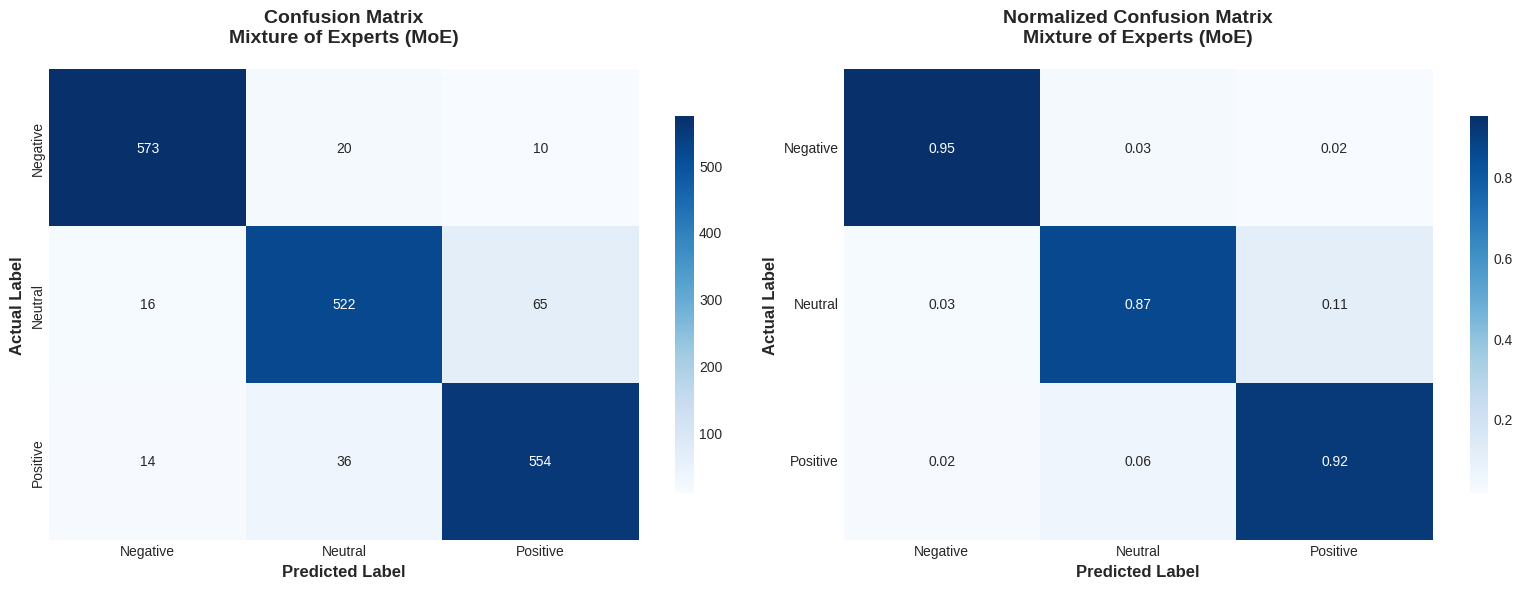


Classification Report - Mixture of Experts (MoE)
              precision    recall  f1-score   support

    Negative      0.950     0.950     0.950       603
     Neutral      0.903     0.866     0.884       603
    Positive      0.881     0.917     0.899       604

    accuracy                          0.911      1810
   macro avg      0.911     0.911     0.911      1810
weighted avg      0.911     0.911     0.911      1810



In [ ]:
# plot for Mixture of Experts (MoE) model
print('\n' + '='*60)
print('MIXTURE OF EXPERTS (MoE) Model Evaluation')
print('='*60)
cm_moe = plot_confusion_matrix_with_metrics(
    y_test,
    all_preds_moe,
    model_name='Mixture of Experts (MoE)',
    cmap='Blues'
)


Meta-Mixture of Experts (Meta-MoE) Model EVALUATION


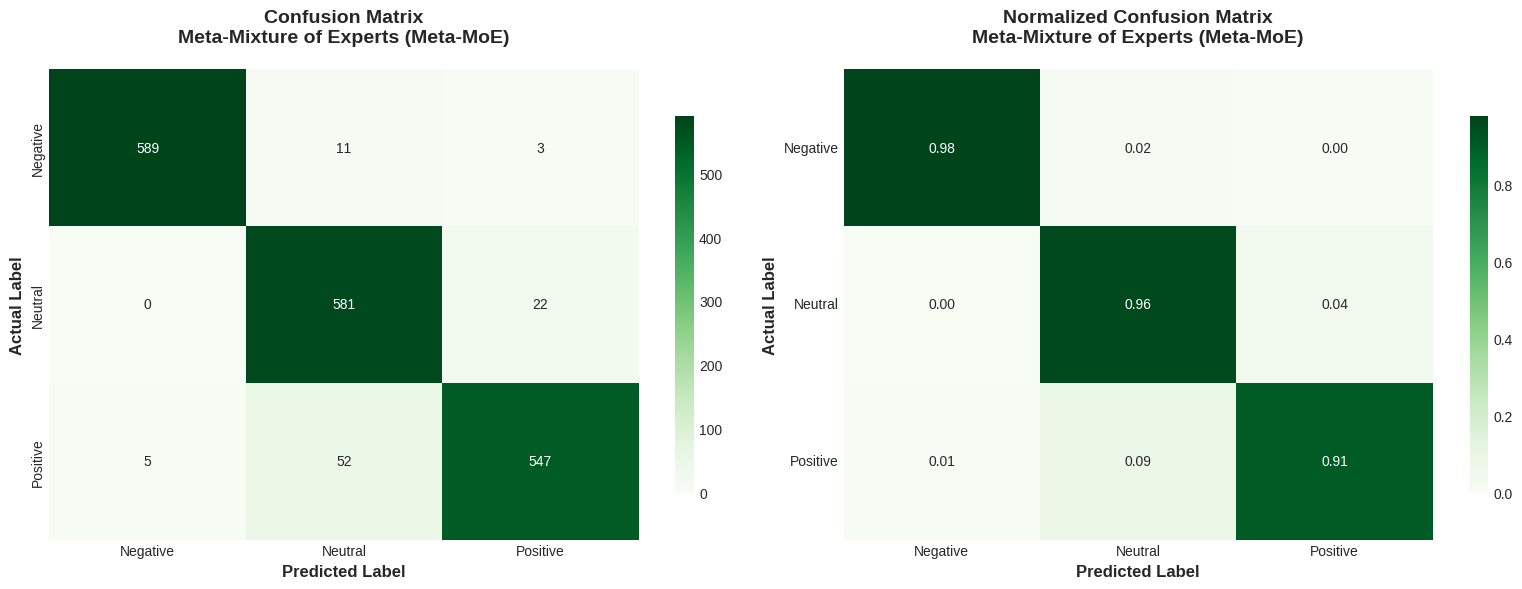


Classification Report - Meta-Mixture of Experts (Meta-MoE)
              precision    recall  f1-score   support

    Negative      0.992     0.977     0.984       603
     Neutral      0.902     0.964     0.932       603
    Positive      0.956     0.906     0.930       604

    accuracy                          0.949      1810
   macro avg      0.950     0.949     0.949      1810
weighted avg      0.950     0.949     0.949      1810



In [ ]:
# plot for Meta-Mixture of Experts (Meta-MoE) model
print('\n' + '='*60)
print('Meta-Mixture of Experts (Meta-MoE) Model EVALUATION')
print('='*60)
cm_momoe = plot_confusion_matrix_with_metrics(
    meta_y,
    meta_preds,
    model_name='Meta-Mixture of Experts (Meta-MoE)',
    cmap='Greens'
)

In [ ]:
# Additional: Compare model performance
def calculate_accuracy(cm):
    """Calculate accuracy from confusion matrix"""
    return np.trace(cm) / np.sum(cm)

moe_accuracy = calculate_accuracy(cm_moe)
momoe_accuracy = calculate_accuracy(cm_momoe)

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"Mixture of Experts (MoE) Accuracy: {moe_accuracy:.3f}")
print(f"Meta-Mixture of Experts (Meta-MoE) Accuracy: {momoe_accuracy:.3f}")
print(f"Accuracy Difference: {momoe_accuracy - moe_accuracy:.3f}")



MODEL COMPARISON SUMMARY
Mixture of Experts (MoE) Accuracy: 0.911
Meta-Mixture of Experts (Meta-MoE) Accuracy: 0.949
Accuracy Difference: 0.038


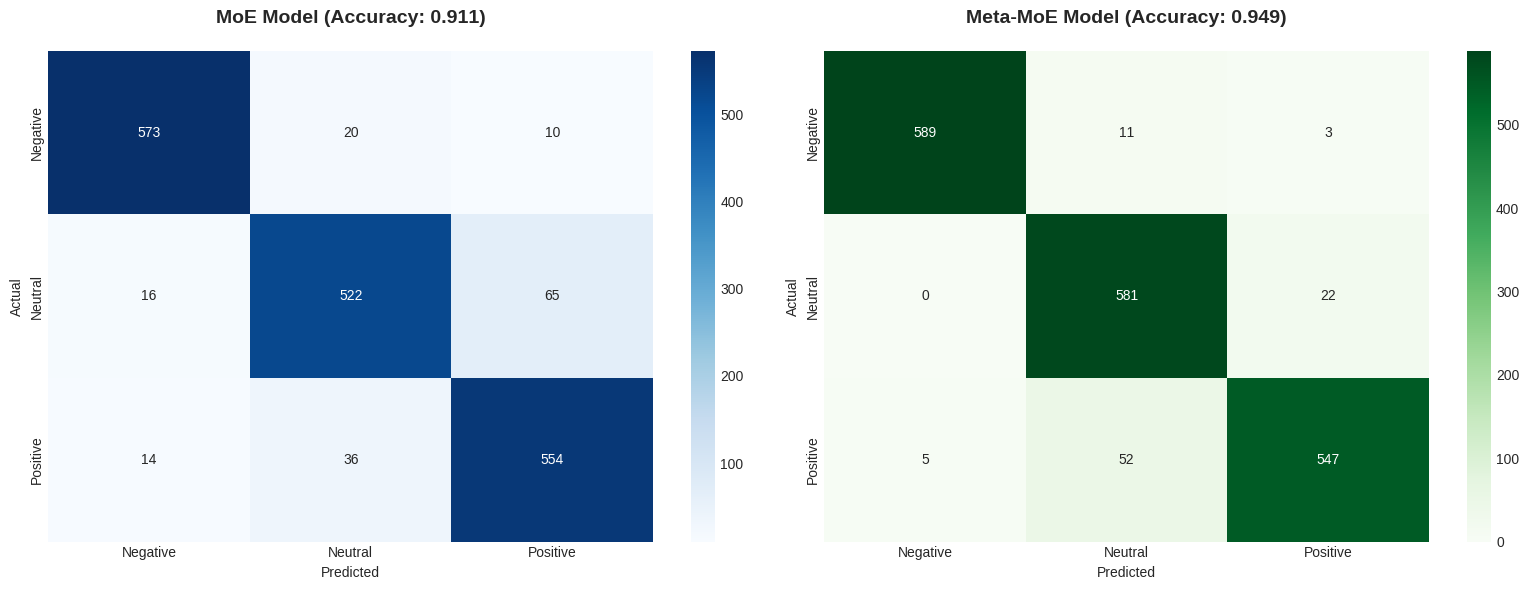

In [ ]:
# Optional: Side-by-side comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# MoE plot
sns.heatmap(cm_moe, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'], ax=ax1)
ax1.set_title(f"MoE Model (Accuracy: {moe_accuracy:.3f})", fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel("Predicted")
ax1.set_ylabel("Actual")

# Meta-MoE plot
sns.heatmap(cm_momoe, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'], ax=ax2)
ax2.set_title(f"Meta-MoE Model (Accuracy: {momoe_accuracy:.3f})", fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel("Predicted")
ax2.set_ylabel("Actual")

plt.tight_layout()
plt.show()